# Supplemental Analyses

Supplementary tables, figures, validation checks, and sensitivity analyses using `data/analysis/analysis_dataset_enriched_v2.csv`.


# 1. Setup and Configuration

First, we import the necessary libraries and set up the key configuration variables for our analysis. **Please edit these variables to match your file paths and column names.**

We also load the dataset and prepare it for analysis e.g., creating a numeric version of our policy claim variable

## Install packages

In [ ]:
# --- ENVIRONMENT CHECK ---
import sys
import subprocess

print(f"Python version: {sys.version.split()[0]}")

# --- REQUIRED PACKAGES ---
required = [
    "pandas", "numpy", "matplotlib", "seaborn", "ydata_profiling",
    "statsmodels", "nltk", "python-docx"
]

for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", pkg],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
        except subprocess.CalledProcessError:
            print(f"Warning: could not install '{pkg}'. Install it manually.")

# --- MATPLOTLIB BACKEND ---
%matplotlib inline
import matplotlib as mpl
print(f"Matplotlib backend: {mpl.get_backend()}")


## load dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- SINGLE DATA LOAD: run this cell once before the analysis cells ---
ROOT = Path("..")
ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
CLAIM_COLUMN = "llm_policy_claim"
JOURNAL_COLUMN = "journal"
YEAR_COLUMN = "publication_year"
FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def rel_path(path: Path) -> str:
    return path.as_posix()


def load_analysis_dataset(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        data = pd.read_csv(path)
    elif path.suffix.lower() == ".json":
        data = pd.read_json(path)
    else:
        raise ValueError(f"Input file must be .csv or .json, got: {rel_path(path)}")

    required = [CLAIM_COLUMN, JOURNAL_COLUMN, YEAR_COLUMN]
    missing = [col for col in required if col not in data.columns]
    if missing:
        raise KeyError(f"Missing required columns in {rel_path(path)}: {missing}")

    print(f"Loaded {len(data):,} records from {rel_path(path)}")

    data = data.dropna(subset=[CLAIM_COLUMN]).copy()
    data[YEAR_COLUMN] = pd.to_numeric(data[YEAR_COLUMN], errors="coerce")
    data[JOURNAL_COLUMN] = data[JOURNAL_COLUMN].astype(str).str.title()
    data[CLAIM_COLUMN] = data[CLAIM_COLUMN].astype(bool)
    data["claim"] = data[CLAIM_COLUMN].astype(int)

    print(f"Analytic rows after dropping missing {CLAIM_COLUMN}: {len(data):,}")
    print("Claim counts:\n" + data[CLAIM_COLUMN].value_counts(dropna=False).to_string())
    if "design_combined" in data.columns:
        n_design = int(data["design_combined"].ne("Other/None").sum())
        print(f"Rows with design_combined != Other/None: {n_design:,}")

    return data.reset_index(drop=True)


analysis_df = load_analysis_dataset(ANALYSIS_DATA_FILE)
df = analysis_df.copy()
df.head()


Loaded 45,807 records from ../data/analysis/analysis_dataset_enriched_v2.csv
Analytic rows after dropping missing llm_policy_claim: 45,807
Claim counts:
llm_policy_claim
False    34072
True     11735
Rows with design_combined != Other/None: 15,075


,scopus_id,doi,title,journal,publication_year,keywords,abstract,article_type,corresponding_author_country,cited_by_count,...,design_abstract,design_strict,design_keywords,design_combined,design_combined_unambiguous,is_methodological,is_excluded_sensitivity,is_policy_analysis_eval,is_methods_qe,bold_policy_claim
0,SCOPUS_ID:0025248647,NaN,"Epidemic dengue 1 in Brazil, 1986: Evaluation ...",American Journal Of Epidemiology,1990,Dengue; Enzyme-linked immunosorbent assay; Epi...,"In the last 15 years, dengue fever has emerged...",article,UNITED STATES,61,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
1,SCOPUS_ID:0025695891,10.1093/oxfordjournals.aje.a115759,The validity of questionnaire reports of a his...,American Journal Of Epidemiology,1990,Epidemiologic methods; Otitis media; Questionn...,"A random sample of 2,512 children with an esti...",article,FINLAND,53,...,Other/None,Other/None,Other/None,Other/None,Other/None,True,True,False,True,False
2,SCOPUS_ID:0025695889,10.1093/oxfordjournals.aje.a115751,The relation between body mass index and plasm...,American Journal Of Epidemiology,1990,Body weight; Child; Cholesterol; Chronic disea...,The relation between body mass index expressed...,article,UNITED STATES,36,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
3,SCOPUS_ID:0025690158,10.1093/oxfordjournals.aje.a115757,The strong heart study a study of cardiovascul...,American Journal Of Epidemiology,1990,"Cardiovascular disease; Indians, North America...",Available data indicate that cardiovascular di...,article,UNITED STATES,528,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False
4,SCOPUS_ID:0025681563,10.1093/oxfordjournals.aje.a115761,The effects of measurement errors on relatwe r...,American Journal Of Epidemiology,1990,Regression analysis; Risk; Statistics,This paper concerns the effects of random erro...,article,CANADA,204,...,Other/None,Other/None,Other/None,Other/None,Other/None,False,False,False,False,False


# Supplemental

## Supp Table: Journals used

In [ ]:
import re
import pandas as pd
from pathlib import Path
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
import numpy as np
from io import StringIO

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of the candidate columns found: {candidates}")

def pick_col_optional(df, candidates, default=None):
    for c in candidates:
        if c in df.columns:
            return c
    return default

def most_common_nonnull(s: pd.Series) -> str:
    if s is None:
        return ""
    s = s.dropna().astype(str).str.strip()
    return "" if s.empty else s.value_counts().index[0]

def fmt(x):
    if isinstance(x, (np.integer, int)):
        return f"{int(x):,}"
    if isinstance(x, (np.floating, float)):
        return f"{x:.0f}"
    return "" if pd.isna(x) else str(x)

def norm_jname(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s*&\s*", " and ", s) 
    s = re.sub(r"\.", "", s) 
    s = re.sub(r" \(.*\)", "", s) 
    s = re.sub(r"\s+", " ", s) 
    return s

def clean_scopus_if_raw(x):
    s = str(x)
    if s.startswith("S"):
        return s
    m = re.search(r"(\d{5,})", s)
    return f"S{m.group(1)}" if m else s

desired_rows = [
    ("International Journal of Epidemiology",           "S27024",      "0300-5771"),
    ("American Journal of Preventive Medicine",         "S20224",      "0749-3797"),
    ("Preventive Medicine",                             "S20040",      "0091-7435"),
    ("Epidemiology",                                    "S15470582",   "1044-3983"),
    ("Journal of Epidemiology and Community Health",    "S156988948",  "0143-005X"), 
    ("The Lancet Public Health",                        "S2764808104", "2468-2667"),
    ("American Journal of Public Health",               "S168049282",  "0090-0036"),
    ("European Journal of Public Health",               "S4210220588", "1101-1262"),
    ("American Journal of Epidemiology",                "S170967050",  "0002-9262"),
    ("European Journal of Epidemiology",                "S48690275",   "0393-2990"),
]
table1 = pd.DataFrame(desired_rows, columns=["Journal Name", "Scopus ID desired", "ISSN desired"])
table1["__jkey"] = table1["Journal Name"].map(norm_jname)

# This supplemental notebook is self-contained: load raw records and recreate
# the filtered corpus if these objects were not created by an earlier cell.
if "df_raw" not in globals() or "kept" not in globals():
    import importlib.util

    script = Path("./2_filter_records.py")
    if not script.exists():
        script = Path("../code/2_filter_records.py")
    if not script.exists():
        raise FileNotFoundError("Could not find 2_filter_records.py from the notebook working directory.")

    spec = importlib.util.spec_from_file_location("filter_records", script)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)

    in_dir = Path("../data/json_files")
    files = sorted(in_dir.glob("*.json"))
    if not files:
        fallback = in_dir / "filtered" / "all_abstracts.json"
        if not fallback.exists():
            raise FileNotFoundError(f"No raw JSON files in {in_dir} and no fallback at {fallback}")
        print(f"No raw JSON files found; loading combined file: {fallback.as_posix()}")
        files = [fallback]

    records = []
    for path in files:
        records.extend(mod.load_json(path))

    df_raw = pd.DataFrame.from_records(records)
    kept, dropped, counts = mod.filter_df(df_raw)
    print(f"Loaded raw records: {len(df_raw):,}")
    print(f"Kept after content filters: {len(kept):,}")
    print(f"Dropped after content filters: {len(dropped):,}")

JCOL   = pick_col(df_raw, ["journal", "source_title", "journal_name"])
YEAR   = pick_col(df_raw, ["publication_year", "year"])
SCOPUS = pick_col_optional(df_raw, ["scopus_id", "source_id", "journal_scopus_id"])
ISSN   = pick_col_optional(df_raw, ["issn", "print_issn", "e_issn", "issn_print", "eissn"])

df_raw = df_raw.copy()
kept = kept.copy()

df_raw[YEAR] = pd.to_numeric(df_raw[YEAR], errors="coerce")
kept[YEAR]   = pd.to_numeric(kept[YEAR], errors="coerce")

df_raw["__jkey"] = df_raw[JCOL].map(norm_jname)
kept["__jkey"] = kept[JCOL].map(norm_jname)

print("Aggregating stats from raw data...")
cnt_total = df_raw.groupby("__jkey").size().rename("N (total)")

cnt_kept = kept.groupby("__jkey").size().rename("N (excluding missing abstracts, commentaries and review)")

agg_specs = {
    "y_min": (YEAR, "min"),
    "y_max": (YEAR, "max"),
}

if SCOPUS is not None:
    agg_specs["Scopus_raw"] = (SCOPUS, most_common_nonnull)
    
if ISSN is not None:
    agg_specs["ISSN_raw"] = (ISSN, most_common_nonnull)
    
df_agg = df_raw.groupby("__jkey").agg(**agg_specs)

table1 = table1.merge(cnt_total, on="__jkey", how="left")
table1 = table1.merge(cnt_kept, on="__jkey", how="left")
table1 = table1.merge(df_agg, on="__jkey", how="left")

if "Scopus_raw" not in table1.columns:
    table1["Scopus_raw"] = None
    
if "ISSN_raw" not in table1.columns:
    table1["ISSN_raw"] = None

table1["N (total)"] = table1["N (total)"].fillna(0).astype(int)
table1["N (excluding missing abstracts, commentaries and review)"] = \
    table1["N (excluding missing abstracts, commentaries and review)"].fillna(0).astype(int)

table1["Years"] = table1.apply(
    lambda r: f"{int(r['y_min'])}-{int(r['y_max'])}" if pd.notna(r['y_min']) and pd.notna(r['y_max']) else "", 
    axis=1
)

table1["Scopus ID"] = table1["Scopus ID desired"].fillna(table1["Scopus_raw"])
table1["ISSN"] = table1["ISSN desired"].fillna(table1["ISSN_raw"])
table1["Scopus ID"] = table1["Scopus ID"].map(clean_scopus_if_raw).fillna("")
table1["ISSN"] = table1["ISSN"].fillna("")

final_cols = [
    "Journal Name",
    "Scopus ID",
    "ISSN",
    "Years",
    "N (total)",
    "N (excluding missing abstracts, commentaries and review)",
]
table1 = table1[final_cols]

table1 = table1.sort_values("N (total)", ascending=False).reset_index(drop=True)

table1.loc[len(table1)] = {
    "Journal Name": "Total", 
    "Scopus ID": "",
    "ISSN": "",
    "Years": "",
    "N (total)": table1["N (total)"].sum(),
    "N (excluding missing abstracts, commentaries and review)":
        table1["N (excluding missing abstracts, commentaries and review)"].sum(),
}

print(table1.to_string(index=False))

doc = Document()
doc.add_heading("Supplementary Table 1. Journals Used", level=1)
table = doc.add_table(rows=1, cols=len(table1.columns))
table.alignment = WD_TABLE_ALIGNMENT.LEFT
hdr = table.rows[0].cells
for i, col in enumerate(table1.columns):
    hdr[i].text = str(col)

for _, r in table1.iterrows():
    cells = table.add_row().cells
    for i, val in enumerate(r.tolist()):
        cells[i].text = fmt(val)

out_dir = Path("../table")
out_dir.mkdir(parents=True, exist_ok=True)
doc_path = out_dir / "supp_table1_journals_used.docx"
doc.save(doc_path)

print("\nDone. Table saved to Supplementary_Table_1.docx")


## Supp Table: Policy claims excluding methodological papers (conservative cutoff)

In [8]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

import pandas as pd
import numpy as np
from IPython.display import HTML

# is_methodological is already computed by 5_add_study_design_and_topics.py
# and present in df.

n_method = df['is_methodological'].sum()
n_total  = len(df)
print(f"Identified {n_method} methodological papers ({n_method/n_total*100:.1f}%).")

df_filtered = df[~df['is_methodological']].copy()
print(f"Remaining papers: {len(df_filtered)} / {n_total} ({len(df_filtered)/n_total*100:.1f}%)")

# STEP 2. Run the Table 1 descriptive statistics on filtered dataset
# -----------------------------------------------------------------------------------

# Define time periods
periods = {
    '1990-1999': (1990, 2000),
    '2000-2009': (2000, 2010),
    '2010-2019': (2010, 2020),
    '2020-2024': (2020, 2025),
    'All years': (1990, 2025)
}

# Get top 10 journals and top 15 countries
top_10_journals = df_filtered['journal'].value_counts().head(10).index.tolist()
top_15_countries = df_filtered['corresponding_author_country'].value_counts().head(15).index.tolist()

# Sort journals by 2020–2024 policy claim rate
period_2020_df = df_filtered[
    (df_filtered['publication_year'] >= 2020) & (df_filtered['publication_year'] < 2025)
]

journal_policy_rates = {}
for journal in top_10_journals:
    jdf = period_2020_df[period_2020_df['journal'] == journal]
    journal_policy_rates[journal] = (jdf['claim'] == 1).mean() * 100 if len(jdf) else 0
sorted_journals = sorted(journal_policy_rates, key=journal_policy_rates.get)

# Sort countries by 2020–2024 policy claim rate
country_policy_rates = {}
for country in top_15_countries:
    cdf = period_2020_df[period_2020_df['corresponding_author_country'] == country]
    country_policy_rates[country] = (cdf['claim'] == 1).mean() * 100 if len(cdf) else 0
sorted_countries = sorted(country_policy_rates, key=country_policy_rates.get)

# Initialize result containers
results, row_names, categories = {}, [], []
metrics = [
    'Number of articles, N',
    'Number of unique journals, N',
    'Words in abstracts, mean (SD)',
    'Papers with keywords included, %',
    'Countries of corresponding author, N',
    'Policy claims, N (%)'
]

for metric in metrics:
    results[metric] = {}
    row_names.append(metric)
    categories.append('')

# Add section headers
results['  All journals/countries'] = {}
row_names.append('  All journals/countries')
categories.append('')

results['Journals, policy claim rate (%)'] = {}
row_names.append('Journals, policy claim rate (%)')
categories.append('Journal')

for j in sorted_journals:
    results[f'  {j}'] = {}
    row_names.append(f'  {j}')
    categories.append('Journal')

results['Countries (first author), policy claim rate (%)'] = {}
row_names.append('Countries (first author), policy claim rate (%)')
categories.append('Country')

for c in sorted_countries:
    cf = c.capitalize() if isinstance(c, str) else c
    results[f'  {cf}'] = {}
    row_names.append(f'  {cf}')
    categories.append('Country')

# Loop through each period
for period_name, (start_year, end_year) in periods.items():
    period_df = df_filtered[
        (df_filtered['publication_year'] >= start_year) &
        (df_filtered['publication_year'] < end_year)
    ]
    n_articles = len(period_df)

    results['Number of articles, N'][period_name] = n_articles
    results['Number of unique journals, N'][period_name] = period_df['journal'].nunique()

    # Abstract word stats
    wc = period_df['abstract'].fillna('').str.split().str.len()
    results['Words in abstracts, mean (SD)'][period_name] = (
        f"{wc.mean():.1f} ({wc.std():.1f})" if not wc.empty else "N/A"
    )

    # Keywords present
    def has_keywords(x):
        if pd.isna(x):
            return False
        if isinstance(x, list) and len(x) == 0:
            return False
        if isinstance(x, str) and (x.strip() == '' or x.strip() == '[]'):
            return False
        return True

    pct_kw = period_df['keywords'].apply(has_keywords).mean() * 100 if n_articles else 0
    results['Papers with keywords included, %'][period_name] = f"{pct_kw:.1f}"

    # Country diversity
    results['Countries of corresponding author, N'][period_name] = period_df['corresponding_author_country'].nunique()

    # Policy claims
    n_policy = (period_df['claim'] == 1).sum()
    pct_policy = (n_policy / n_articles * 100) if n_articles else 0
    results['Policy claims, N (%)'][period_name] = f"{n_policy} ({pct_policy:.1f})"
    results['  All journals/countries'][period_name] = f"{pct_policy:.1f}"

    # Journal-specific
    results['Journals, policy claim rate (%)'][period_name] = ""
    for j in sorted_journals:
        jdf = period_df[period_df['journal'] == j]
        pct = (jdf['claim'] == 1).mean() * 100 if len(jdf) else np.nan
        results[f'  {j}'][period_name] = f"{pct:.1f}" if not np.isnan(pct) else "N/A"

    # Country-specific
    results['Countries (first author), policy claim rate (%)'][period_name] = ""
    for c in sorted_countries:
        cf = c.capitalize() if isinstance(c, str) else c
        cdf = period_df[period_df['corresponding_author_country'] == c]
        pct = (cdf['claim'] == 1).mean() * 100 if len(cdf) else np.nan
        results[f'  {cf}'][period_name] = f"{pct:.1f}" if not np.isnan(pct) else "N/A"

# Build Table 1
table1 = pd.DataFrame(results).T
table1.index.name = None

# Pretty HTML formatting
def format_table_html(table_df, row_names):
    html = "<table border='1' cellpadding='8'><tr><th></th>"
    for col in table_df.columns:
        html += f"<th>{col}</th>"
    html += "</tr>"

    for name in row_names:
        style = (
            "font-weight:bold;"
            if name in [
                'Journals, policy claim rate (%)',
                'Countries (first author), policy claim rate (%)'
            ]
            else ""
        )
        html += f"<tr><td style='{style}'>{name}</td>"
        for col in table_df.columns:
            html += f"<td>{table_df.loc[name, col]}</td>"
        html += "</tr>"

    html += "</table>"
    return html

print("\nTable 1: Descriptive Statistics by Time Period (Non-Methodological Papers)")
print("=" * 120)
print(table1.to_string())
display(HTML(format_table_html(table1, row_names)))


Identified 1690 methodological papers (3.7%).
Remaining papers: 44117 / 45807 (96.3%)

Table 1: Descriptive Statistics by Time Period (Non-Methodological Papers)
                                                    1990-1999     2000-2009     2010-2019     2020-2024     All years
Number of articles, N                                    9961         12156         14955          7045         44117
Number of unique journals, N                                9             9            10            10            10
Words in abstracts, mean (SD)                    206.0 (67.9)  216.3 (55.4)  221.2 (52.2)  239.3 (57.5)  219.3 (58.7)
Papers with keywords included, %                         47.4          59.8          44.3          56.4          51.2
Countries of corresponding author, N                      113           119           122           103           154
Policy claims, N (%)                              1818 (18.3)   2820 (23.2)   4326 (28.9)   2606 (37.0)  11570 (26.2)
  All journa

,1990-1999,2000-2009,2010-2019,2020-2024,All years
"Number of articles, N",9961,12156,14955,7045,44117
"Number of unique journals, N",9,9,10,10,10
"Words in abstracts, mean (SD)",206.0 (67.9),216.3 (55.4),221.2 (52.2),239.3 (57.5),219.3 (58.7)
"Papers with keywords included, %",47.4,59.8,44.3,56.4,51.2
"Countries of corresponding author, N",113,119,122,103,154
"Policy claims, N (%)",1818 (18.3),2820 (23.2),4326 (28.9),2606 (37.0),11570 (26.2)
All journals/countries,18.3,23.2,28.9,37.0,26.2
"Journals, policy claim rate (%)",,,,,
Epidemiology,1.2,4.4,5.0,6.2,4.1
European Journal Of Epidemiology,19.3,15.3,10.2,14.7,14.6


In [10]:
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
import os

doc = Document()
doc.add_heading('Descriptive statistics by time period (non-methodological papers)', level=1)

out = table1.copy()
out.insert(0, 'Row', out.index)
out = out.reset_index(drop=True)

cols = out.columns.tolist()
t = doc.add_table(rows=1, cols=len(cols), style="Table Grid")
for j, h in enumerate(cols):
    cell = t.rows[0].cells[j]
    run = cell.paragraphs[0].add_run(str(h))
    run.bold = True
for _, row in out.iterrows():
    cells = t.add_row().cells
    for j, v in enumerate(row.tolist()):
        txt = "" if (v is None or (isinstance(v, float) and pd.isna(v))) else str(v)
        p = cells[j].paragraphs[0]
        p.add_run(txt)
        p.alignment = WD_ALIGN_PARAGRAPH.LEFT if j == 0 else WD_ALIGN_PARAGRAPH.RIGHT

t.alignment = WD_TABLE_ALIGNMENT.CENTER

save_dir = "../table"
os.makedirs(save_dir, exist_ok=True)
doc_path = os.path.join(save_dir, "supp_table_no_methods_papers.docx")
doc.save(doc_path)
print(f"Saved to: {doc_path}")

Saved to: ../table/supp_table_no_methods_papers.docx


## Supp Table: Policy claims excluding policy-analysis/evaluation and methods papers (broad cutoff)


In [11]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

import pandas as pd
import numpy as np
from IPython.display import HTML

# is_excluded_sensitivity, is_policy_analysis_eval, and is_methods_qe are
# already computed by 5_add_study_design_and_topics.py and present in df.

n_total = len(df)
n_excluded    = df['is_excluded_sensitivity'].sum()
n_policy_eval = df['is_policy_analysis_eval'].sum()
n_methods_qe  = df['is_methods_qe'].sum()

print(f"Identified {n_excluded} excluded papers ({n_excluded/n_total*100:.1f}%).")
print(f"  - Policy analysis/evaluation terms: {n_policy_eval} ({n_policy_eval/n_total*100:.1f}%)")
print(f"  - Methods / quasi-experimental terms: {n_methods_qe} ({n_methods_qe/n_total*100:.1f}%)")

df_filtered = df[~df['is_excluded_sensitivity']].copy()
print(f"Remaining papers: {len(df_filtered)} / {n_total} ({len(df_filtered)/n_total*100:.1f}%)")

# ------------------------------------------------------------------------------
# # STEP 2. Run the Table 1 descriptive statistics on filtered dataset
# ------------------------------------------------------------------------------
# -----------------------------------------------------------------------------------

periods = {
    '1990-1999': (1990, 2000),
    '2000-2009': (2000, 2010),
    '2010-2019': (2010, 2020),
    '2020-2024': (2020, 2025),
    'All years': (1990, 2025)
}

top_10_journals = df_filtered['journal'].value_counts().head(10).index.tolist()
top_15_countries = df_filtered['corresponding_author_country'].value_counts().head(15).index.tolist()

period_2020_df = df_filtered[
    (df_filtered['publication_year'] >= 2020) & (df_filtered['publication_year'] < 2025)
]

journal_policy_rates = {}
for journal in top_10_journals:
    jdf = period_2020_df[period_2020_df['journal'] == journal]
    journal_policy_rates[journal] = (jdf['claim'] == 1).mean() * 100 if len(jdf) else 0
sorted_journals = sorted(journal_policy_rates, key=journal_policy_rates.get)

country_policy_rates = {}
for country in top_15_countries:
    cdf = period_2020_df[period_2020_df['corresponding_author_country'] == country]
    country_policy_rates[country] = (cdf['claim'] == 1).mean() * 100 if len(cdf) else 0
sorted_countries = sorted(country_policy_rates, key=country_policy_rates.get)

results, row_names, categories = {}, [], []
metrics = [
    'Number of articles, N',
    'Number of unique journals, N',
    'Words in abstracts, mean (SD)',
    'Papers with keywords included, %',
    'Countries of corresponding author, N',
    'Policy claims, N (%)'
]

for metric in metrics:
    results[metric] = {}
    row_names.append(metric)
    categories.append('')

results['  All journals/countries'] = {}
row_names.append('  All journals/countries')
categories.append('')

results['Journals, policy claim rate (%)'] = {}
row_names.append('Journals, policy claim rate (%)')
categories.append('Journal')

for j in sorted_journals:
    results[f'  {j}'] = {}
    row_names.append(f'  {j}')
    categories.append('Journal')

results['Countries (first author), policy claim rate (%)'] = {}
row_names.append('Countries (first author), policy claim rate (%)')
categories.append('Country')

for c in sorted_countries:
    cf = c.capitalize() if isinstance(c, str) else c
    results[f'  {cf}'] = {}
    row_names.append(f'  {cf}')
    categories.append('Country')

for period_name, (start_year, end_year) in periods.items():
    period_df = df_filtered[
        (df_filtered['publication_year'] >= start_year) &
        (df_filtered['publication_year'] < end_year)
    ]
    n_articles = len(period_df)

    results['Number of articles, N'][period_name] = n_articles
    results['Number of unique journals, N'][period_name] = period_df['journal'].nunique()

    wc = period_df['abstract'].fillna('').str.split().str.len()
    results['Words in abstracts, mean (SD)'][period_name] = (
        f"{wc.mean():.1f} ({wc.std():.1f})" if not wc.empty else "N/A"
    )

    def has_keywords(x):
        if pd.isna(x):
            return False
        if isinstance(x, list) and len(x) == 0:
            return False
        if isinstance(x, str) and (x.strip() == '' or x.strip() == '[]'):
            return False
        return True

    pct_kw = period_df['keywords'].apply(has_keywords).mean() * 100 if n_articles else 0
    results['Papers with keywords included, %'][period_name] = f"{pct_kw:.1f}"

    results['Countries of corresponding author, N'][period_name] = (
        period_df['corresponding_author_country'].nunique()
    )

    n_policy = (period_df['claim'] == 1).sum()
    pct_policy = (n_policy / n_articles * 100) if n_articles else 0
    results['Policy claims, N (%)'][period_name] = f"{n_policy} ({pct_policy:.1f})"
    results['  All journals/countries'][period_name] = f"{pct_policy:.1f}"

    results['Journals, policy claim rate (%)'][period_name] = ""
    for j in sorted_journals:
        jdf = period_df[period_df['journal'] == j]
        pct = (jdf['claim'] == 1).mean() * 100 if len(jdf) else np.nan
        results[f'  {j}'][period_name] = f"{pct:.1f}" if not np.isnan(pct) else "N/A"

    results['Countries (first author), policy claim rate (%)'][period_name] = ""
    for c in sorted_countries:
        cf = c.capitalize() if isinstance(c, str) else c
        cdf = period_df[period_df['corresponding_author_country'] == c]
        pct = (cdf['claim'] == 1).mean() * 100 if len(cdf) else np.nan
        results[f'  {cf}'][period_name] = f"{pct:.1f}" if not np.isnan(pct) else "N/A"

table1 = pd.DataFrame(results).T
table1.index.name = None

def format_table_html(table_df, row_names):
    html = "<table border='1' cellpadding='8'><tr><th></th>"
    for col in table_df.columns:
        html += f"<th>{col}</th>"
    html += "</tr>"
    for name in row_names:
        style = (
            "font-weight:bold;"
            if name in [
                'Journals, policy claim rate (%)',
                'Countries (first author), policy claim rate (%)'
            ]
            else ""
        )
        html += f"<tr><td style='{style}'>{name}</td>"
        for col in table_df.columns:
            html += f"<td>{table_df.loc[name, col]}</td>"
        html += "</tr>"
    html += "</table>"
    return html

print("\nTable 1: Descriptive Statistics by Time Period (excluding policy analysis/evaluation and methods papers)")
print("=" * 120)
print(table1.to_string())
display(HTML(format_table_html(table1, row_names)))


Identified 3501 excluded papers (7.6%).
  - Policy analysis/evaluation terms: 565 (1.2%)
  - Methods / quasi-experimental terms: 3028 (6.6%)
Remaining papers: 42306 / 45807 (92.4%)

Table 1: Descriptive Statistics by Time Period (excluding policy analysis/evaluation and methods papers)
                                                    1990-1999     2000-2009     2010-2019     2020-2024     All years
Number of articles, N                                    9826         11908         14123          6449         42306
Number of unique journals, N                                9             9            10            10            10
Words in abstracts, mean (SD)                    205.9 (67.8)  216.1 (55.4)  220.7 (52.3)  238.8 (57.9)  218.8 (58.8)
Papers with keywords included, %                         47.6          60.0          44.1          56.2          51.2
Countries of corresponding author, N                      113           119           121           101           153
Polic

,1990-1999,2000-2009,2010-2019,2020-2024,All years
"Number of articles, N",9826,11908,14123,6449,42306
"Number of unique journals, N",9,9,10,10,10
"Words in abstracts, mean (SD)",205.9 (67.8),216.1 (55.4),220.7 (52.3),238.8 (57.9),218.8 (58.8)
"Papers with keywords included, %",47.6,60.0,44.1,56.2,51.2
"Countries of corresponding author, N",113,119,121,101,153
"Policy claims, N (%)",1786 (18.2),2759 (23.2),4116 (29.1),2439 (37.8),11100 (26.2)
All journals/countries,18.2,23.2,29.1,37.8,26.2
"Journals, policy claim rate (%)",,,,,
Epidemiology,1.2,4.4,5.4,6.5,4.2
European Journal Of Epidemiology,18.6,15.2,10.2,15.6,14.5


In [ ]:
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
import os

doc = Document()
doc.add_heading('Descriptive statistics by time period (excluding policy-analysis/evaluation and methods papers)', level=1)

out = table1.copy()
out.insert(0, 'Row', out.index)
out = out.reset_index(drop=True)

cols = out.columns.tolist()
t = doc.add_table(rows=1, cols=len(cols), style="Table Grid")
for j, h in enumerate(cols):
    cell = t.rows[0].cells[j]
    run = cell.paragraphs[0].add_run(str(h))
    run.bold = True
for _, row in out.iterrows():
    cells = t.add_row().cells
    for j, v in enumerate(row.tolist()):
        txt = "" if (v is None or (isinstance(v, float) and pd.isna(v))) else str(v)
        p = cells[j].paragraphs[0]
        p.add_run(txt)
        p.alignment = WD_ALIGN_PARAGRAPH.LEFT if j == 0 else WD_ALIGN_PARAGRAPH.RIGHT

t.alignment = WD_TABLE_ALIGNMENT.CENTER

save_dir = "../table"
os.makedirs(save_dir, exist_ok=True)
doc_path = os.path.join(save_dir, "supp_table_no_policy_or_methods_papers.docx")
doc.save(doc_path)
print(f"Saved to: {doc_path}")


## Supp Tables: Denominators by journal, country, and study design

In [15]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

import pandas as pd
from pathlib import Path
from docx import Document
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.text import WD_ALIGN_PARAGRAPH

OUT_DIR = Path("../table")
OUT_DIR.mkdir(parents=True, exist_ok=True)

d = df.copy()
d["claim"] = d["llm_policy_claim"].astype(bool)
d["publication_year"] = pd.to_numeric(d["publication_year"], errors="coerce")
d = d.dropna(subset=["publication_year"]).copy()
d["publication_year"] = d["publication_year"].astype(int)

d["journal"] = d["journal"].astype(str).str.strip()
d["design_combined"] = d["design_combined"].astype(str).str.strip()
d["corresponding_author_country"] = (
    d["corresponding_author_country"]
    .astype(str).str.strip()
    .replace({"": "UNKNOWN", "nan": "UNKNOWN"})
    .str.upper()
)

main_periods = {
    "1990-1999": (1990, 2000),
    "2000-2009": (2000, 2010),
    "2010-2019": (2010, 2020),
    "2020-2024": (2020, 2025),
}

five_year_periods = {
    f"{y}-{min(y+4, 2024)}": (y, min(y+5, 2025))
    for y in range(1990, 2025, 5)
}

top_10_journals = d["journal"].value_counts().head(10).index.tolist()

counts_by_country_year = (
    d.groupby(["corresponding_author_country", "publication_year"])
    .size().unstack(fill_value=0)
)
mean_per_year = counts_by_country_year.mean(axis=1)
eligible_countries = [c for c in mean_per_year[mean_per_year >= 10].index if c != "UNKNOWN"]
df_eligible = df[df["corresponding_author_country"].isin(eligible_countries)].copy()

after_2020 = d[(d["publication_year"] >= 2020) & (d["publication_year"] < 2025)]
sorted_journals = sorted(
    top_10_journals,
    key=lambda j: after_2020.loc[after_2020["journal"].eq(j), "claim"].mean() if len(after_2020.loc[after_2020["journal"].eq(j)]) else 0
)
sorted_countries = sorted(
    eligible_countries,
    key=lambda c: after_2020.loc[after_2020["corresponding_author_country"].eq(c), "claim"].mean() if len(after_2020.loc[after_2020["corresponding_author_country"].eq(c)]) else 0
)

design_order = [
    x for x in [
        "Experimental",
        "Quasi-experimental",
        "Cohort",
        "Case-control",
        "Cross-sectional",
        "Ecological / Time-series",
        "Qualitative",
    ]
    if x in d["design_combined"].unique()
]

def one_group_table(data, group_col, groups, periods):
    rows = []
    for g in groups:
        row = {"label": g}
        for p, (start, end) in periods.items():
            sub = data[
                data[group_col].eq(g)
                & data["publication_year"].ge(start)
                & data["publication_year"].lt(end)
            ]
            n_total = len(sub)
            pct = 100 * sub["claim"].mean() if n_total else pd.NA
            row[f"{p}_n"] = n_total
            row[f"{p}_pct"] = round(pct, 1) if n_total else pd.NA
        rows.append(row)
    return pd.DataFrame(rows)

journal_tbl = one_group_table(d, "journal", sorted_journals, main_periods)
country_tbl = one_group_table(d, "corresponding_author_country", sorted_countries, main_periods)
design_tbl = one_group_table(
    d[d["design_combined"].ne("Other/None")],
    "design_combined",
    design_order,
    main_periods,
)

journal_tbl_5 = one_group_table(d, "journal", sorted_journals, five_year_periods)
country_tbl_5 = one_group_table(d, "corresponding_author_country", sorted_countries, five_year_periods)
design_tbl_5 = one_group_table(
    d[d["design_combined"].ne("Other/None")],
    "design_combined",
    design_order,
    five_year_periods,
)


In [ ]:
# Recreate denominator inputs if this cell is run before the prep cell above.
if "main_periods" not in globals() or "journal_tbl" not in globals():
    # Load the main enriched dataset if this section is run out of order.
    if "df" not in globals():
        from pathlib import Path
        import pandas as pd

        ROOT = Path("..")
        ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
        CLAIM_COLUMN = "llm_policy_claim"
        JOURNAL_COLUMN = "journal"
        YEAR_COLUMN = "publication_year"
        FIGURE_DIR = ROOT / "figures"
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)

        df = pd.read_csv(ANALYSIS_DATA_FILE)
        df = df.dropna(subset=[CLAIM_COLUMN]).copy()
        df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
        df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
        df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
        df["claim"] = df[CLAIM_COLUMN].astype(int)
        analysis_df = df.copy()
        print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

    import pandas as pd
    from pathlib import Path
    from docx import Document
    from docx.enum.table import WD_TABLE_ALIGNMENT
    from docx.enum.text import WD_ALIGN_PARAGRAPH

    OUT_DIR = Path("../table")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    d = df.copy()
    d["claim"] = d["llm_policy_claim"].astype(bool)
    d["publication_year"] = pd.to_numeric(d["publication_year"], errors="coerce")
    d = d.dropna(subset=["publication_year"]).copy()
    d["publication_year"] = d["publication_year"].astype(int)

    d["journal"] = d["journal"].astype(str).str.strip()
    d["design_combined"] = d["design_combined"].astype(str).str.strip()
    d["corresponding_author_country"] = (
        d["corresponding_author_country"]
        .astype(str).str.strip()
        .replace({"": "UNKNOWN", "nan": "UNKNOWN"})
        .str.upper()
    )

    main_periods = {
        "1990-1999": (1990, 2000),
        "2000-2009": (2000, 2010),
        "2010-2019": (2010, 2020),
        "2020-2024": (2020, 2025),
    }

    five_year_periods = {
        f"{y}-{min(y+4, 2024)}": (y, min(y+5, 2025))
        for y in range(1990, 2025, 5)
    }

    top_10_journals = d["journal"].value_counts().head(10).index.tolist()

    counts_by_country_year = (
        d.groupby(["corresponding_author_country", "publication_year"])
        .size().unstack(fill_value=0)
    )
    mean_per_year = counts_by_country_year.mean(axis=1)
    eligible_countries = [c for c in mean_per_year[mean_per_year >= 10].index if c != "UNKNOWN"]
    df_eligible = df[df["corresponding_author_country"].isin(eligible_countries)].copy()

    after_2020 = d[(d["publication_year"] >= 2020) & (d["publication_year"] < 2025)]
    sorted_journals = sorted(
        top_10_journals,
        key=lambda j: after_2020.loc[after_2020["journal"].eq(j), "claim"].mean() if len(after_2020.loc[after_2020["journal"].eq(j)]) else 0
    )
    sorted_countries = sorted(
        eligible_countries,
        key=lambda c: after_2020.loc[after_2020["corresponding_author_country"].eq(c), "claim"].mean() if len(after_2020.loc[after_2020["corresponding_author_country"].eq(c)]) else 0
    )

    design_order = [
        x for x in [
            "Experimental",
            "Quasi-experimental",
            "Cohort",
            "Case-control",
            "Cross-sectional",
            "Ecological / Time-series",
            "Qualitative",
        ]
        if x in d["design_combined"].unique()
    ]

    def one_group_table(data, group_col, groups, periods):
        rows = []
        for g in groups:
            row = {"label": g}
            for p, (start, end) in periods.items():
                sub = data[
                    data[group_col].eq(g)
                    & data["publication_year"].ge(start)
                    & data["publication_year"].lt(end)
                ]
                n_total = len(sub)
                pct = 100 * sub["claim"].mean() if n_total else pd.NA
                row[f"{p}_n"] = n_total
                row[f"{p}_pct"] = round(pct, 1) if n_total else pd.NA
            rows.append(row)
        return pd.DataFrame(rows)

    journal_tbl = one_group_table(d, "journal", sorted_journals, main_periods)
    country_tbl = one_group_table(d, "corresponding_author_country", sorted_countries, main_periods)
    design_tbl = one_group_table(
        d[d["design_combined"].ne("Other/None")],
        "design_combined",
        design_order,
        main_periods,
    )

    journal_tbl_5 = one_group_table(d, "journal", sorted_journals, five_year_periods)
    country_tbl_5 = one_group_table(d, "corresponding_author_country", sorted_countries, five_year_periods)
    design_tbl_5 = one_group_table(
        d[d["design_combined"].ne("Other/None")],
        "design_combined",
        design_order,
        five_year_periods,
    )

def combined_table(periods, journal_df, country_df, design_df):
    cols = ["label"]
    for p in periods:
        cols += [f"{p}_n", f"{p}_pct"]

    out = pd.DataFrame(columns=cols)

    def add_section(title, section_df):
        nonlocal out
        header = pd.DataFrame([{"label": title, **{c: pd.NA for c in cols[1:]}}])
        out = pd.concat([out, header, section_df[cols]], ignore_index=True)

    add_section("Journals, policy claim rate (%)", journal_df)
    add_section("Countries of corresponding author, policy claim rate (%)", country_df)
    add_section("Study design, policy claim rate (%)", design_df)
    return out


table_main = combined_table(main_periods, journal_tbl, country_tbl, design_tbl)
table_5yr = combined_table(five_year_periods, journal_tbl_5, country_tbl_5, design_tbl_5)


def add_period_table_to_doc(doc, df_out, periods, title):
    doc.add_heading(title, level=1)
    doc.add_paragraph(
        "Number = total included articles in that stratum and period. "
        "% = percentage of included articles in that stratum and period classified as policy claims."
    )

    ncols = 1 + 2 * len(periods)
    t = doc.add_table(rows=2, cols=ncols, style="Table Grid")
    t.alignment = WD_TABLE_ALIGNMENT.CENTER

    t.cell(0, 0).text = ""
    t.cell(0, 0).merge(t.cell(1, 0))

    col_idx = 1
    for p in periods:
        t.cell(0, col_idx).text = p
        t.cell(0, col_idx).merge(t.cell(0, col_idx + 1))
        t.cell(1, col_idx).text = "Number"
        t.cell(1, col_idx + 1).text = "%"
        col_idx += 2

    for r in range(2):
        for c in range(ncols):
            for para in t.cell(r, c).paragraphs:
                para.alignment = WD_ALIGN_PARAGRAPH.CENTER
                for run in para.runs:
                    run.bold = True

    section_headers = {
        "Journals, policy claim rate (%)",
        "Countries of corresponding author, policy claim rate (%)",
        "Study design, policy claim rate (%)",
    }

    for _, row in df_out.iterrows():
        cells = t.add_row().cells
        label = row["label"]
        is_section = label in section_headers

        p0 = cells[0].paragraphs[0]
        p0.alignment = WD_ALIGN_PARAGRAPH.LEFT
        run0 = p0.add_run(str(label))
        run0.bold = is_section

        c = 1
        for p in periods:
            n_val = row[f"{p}_n"]
            pct_val = row[f"{p}_pct"]

            cells[c].text = "" if pd.isna(n_val) else f"{int(n_val)}"
            cells[c + 1].text = "" if pd.isna(pct_val) else f"{float(pct_val):.1f}%"

            cells[c].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
            cells[c + 1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
            c += 2


doc1 = Document()
add_period_table_to_doc(
    doc1,
    table_main,
    list(main_periods.keys()),
    "Supplementary denominator table by journal, country, and study design: main period groupings",
)
file1 = OUT_DIR / "supp_table_denominator_table_main_periods.docx"
doc1.save(file1)

doc2 = Document()
add_period_table_to_doc(
    doc2,
    table_5yr,
    list(five_year_periods.keys()),
    "Supplementary denominator table by journal, country, and study design: 5-year period groupings",
)
file2 = OUT_DIR / "supp_table_denominator_table_5year_periods.docx"
doc2.save(file2)

print(f"Saved: {file1.as_posix()}")
print(f"Saved: {file2.as_posix()}")


Saved: ../table/supp_table6_denominator_table_main_periods.docx
Saved: ../table/supp_table7_denominator_table_5year_periods.docx


/var/folders/jn/q49x_b756ws_66x7djlfvhs00000gp/T/ipykernel_50584/927546974.py:139: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat([out, header, section_df[cols]], ignore_index=True)
/var/folders/jn/q49x_b756ws_66x7djlfvhs00000gp/T/ipykernel_50584/927546974.py:139: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat([out, header, section_df[cols]], ignore_index=True)
/var/folders/jn/q49x_b756ws_66x7djlfvhs00000gp/T/ipykernel_50584/927546974.py:139: FutureWarning: The beha

## Supp Fig: LOESS policy claim % by first author country

In [ ]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

# --- LOESS-smoothed percent plot by country
yearly_percent_country = (
    df_eligible.groupby([YEAR_COLUMN, 'corresponding_author_country'])['claim']
    .mean()
    .reset_index()
)
yearly_percent_country.rename(columns={'claim': 'percent_claim'}, inplace=True)
yearly_percent_country['percent_claim'] *= 100

from statsmodels.nonparametric.smoothers_lowess import lowess

def _loess_group(d, frac=0.45):
    d = d.sort_values(YEAR_COLUMN).copy()
    d['smoothed_percent'] = lowess(d['percent_claim'], d[YEAR_COLUMN],
                                   frac=frac, it=1, return_sorted=False)
    return d

smoothed_country_loess = (
    yearly_percent_country
    .groupby('corresponding_author_country', group_keys=False)
    .apply(_loess_group)
)

# Order legend by latest year
latest_year_c_loess = smoothed_country_loess[YEAR_COLUMN].max()
legend_order_c_loess_df = (
    smoothed_country_loess[smoothed_country_loess[YEAR_COLUMN] == latest_year_c_loess]
    .sort_values(by='smoothed_percent', ascending=False)
)
legend_order_c_loess = legend_order_c_loess_df['corresponding_author_country'].tolist()
smoothed_country_loess['corresponding_author_country'] = pd.Categorical(
    smoothed_country_loess['corresponding_author_country'],
    categories=legend_order_c_loess, ordered=True
)

# Plot
plt.figure(figsize=(14, max(6, 0.4*len(legend_order_c_loess))))
sns.lineplot(
    data=smoothed_country_loess,
    x=YEAR_COLUMN,
    y='smoothed_percent',
    hue='corresponding_author_country',
    marker='o'
)

from matplotlib.ticker import MultipleLocator
ax = plt.gca()
ax.set_ylim(0, 50)
ax.yaxis.set_major_locator(MultipleLocator(5))

plt.title('Policy Claim Percentage by First Author Country', fontsize=14)
plt.ylabel('% with Policy Claim (LOESS)')
plt.xlabel('Publication Year')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'supp1_yearly_percent_by_country_loess.png')
plt.show()


## Supp Fig: Policy claims by keyword/topic, by year

In [ ]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

# Temporal Analysis of Policy Claim Rates by Keyword
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import re
import pandas as pd
from matplotlib.patches import Patch

# --- PLOT SETUP ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(24, 14))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]
fig.suptitle('Evolution of Policy Claim Rates by Keyword Across Time Periods', 
             fontsize=24, fontweight='bold', y=0.98)

# --- KEYWORD PROCESSING (same as original) ---
def process_keywords(keyword_data):
    """Extract and clean keywords from semicolon-separated string or list."""
    if isinstance(keyword_data, (list, tuple)):
        parts = keyword_data
    elif pd.isna(keyword_data):
        return []
    else:
        s = str(keyword_data).strip()
        if s in ('', '[]', '[ ]'):
            return []
        parts = [k.strip().strip("'\" ") for k in s.split(';')]
    return [k.lower().strip() for k in parts if k.strip() and len(k.strip()) > 1]


# --- CONSOLIDATION MAPPING (same as original) ---
keyword_mapping = {
    'health inequalities': 'health inequalities',
    'health disparities': 'health inequalities',
    'disparities': 'health inequalities',
    'social inequalities': 'health inequalities',
    'inequalities': 'health inequalities',
    'healthcare disparities': 'health inequalities',
    'tobacco use': 'tobacco',
    'tobacco control': 'tobacco',
    'smoking': 'tobacco',
    'cigarette smoking': 'tobacco',
    'domestic violence': 'domestic violence',
    'intimate partner violence': 'domestic violence',
    'partner violence': 'domestic violence',
    'family violence': 'domestic violence',
    'spouse abuse': 'domestic violence',
    'physical activity': 'physical activity',
    'exercise': 'physical activity',
    'motor activity': 'physical activity',
    'obesity': 'obesity',
    'overweight': 'obesity',
    'breast neoplasms': 'breast cancer',
    'breast cancer': 'breast cancer',
    'colorectal neoplasms': 'colorectal cancer',
    'colorectal cancer': 'colorectal cancer',
    'lung neoplasms': 'lung cancer',
    'lung cancer': 'lung cancer',
    'cervical cancer': 'cervical cancer',
    'cervical neoplasms': 'cervical cancer',
    'cardiovascular diseases': 'cardiovascular disease',
    'cardiovascular disease': 'cardiovascular disease',
    'heart disease': 'cardiovascular disease',
    'coronary disease': 'cardiovascular disease',
    'diabetes mellitus': 'diabetes',
    'diabetes': 'diabetes',
    'mental health': 'mental health',
    'mental disorders': 'mental health',
    'depression': 'depression',
    'depressive disorder': 'depression',
    'alcohol drinking': 'alcohol',
    'alcoholism': 'alcohol',
    'alcohol': 'alcohol',
}

# --- COLOUR SCHEME (same as original) ---
keyword_colors = {
    # Life stages
    'child': '#1976D2', 'adolescent': '#1976D2', 'adolescents': '#1976D2',
    'youth': '#1976D2', 'pregnancy': '#1976D2', 'aged': '#1976D2', 'child health': '#1976D2',
    'children': '#1976D2', 'women': '#1976D2',
    
    # Inequality/Poverty
    'health inequalities': '#7B1FA2', 'poverty': '#7B1FA2', 'socioeconomic factors': '#7B1FA2',
    
    # Study Methods
    'epidemiology': '#00BFA5', 'cohort studies': '#00BFA5', 'case-control studies': '#00BFA5',
    'epidemiologic methods': '#00BFA5', 'cohort study': '#00BFA5', 'surveillance': '#00BFA5',
    
    # Health Outcomes
    'mortality': '#D32F2F', 'morbidity': '#D32F2F', 'incidence': '#D32F2F',
    'cardiovascular disease': '#D32F2F', 'diabetes': '#D32F2F', 'breast cancer': '#D32F2F',
    'cervical cancer': '#D32F2F', 'tuberculosis': '#D32F2F', 'covid-19': '#D32F2F',
    'hiv': '#D32F2F', 'mental health': '#D32F2F', 'cancer': '#D32F2F', 
    'hypertension': '#D32F2F', 'sars-cov-2': '#D32F2F',
    
    # Behavioral Risk
    'obesity': '#F57C00', 'physical activity': '#F57C00', 'diet': '#F57C00',
    'body mass index': '#F57C00', 'tobacco': '#F57C00', 'smoking': '#F57C00', 'alcohol': '#F57C00',
    'risk factors': '#F57C00', 'smoking cessation': '#F57C00',
    
    # Policy/Intervention
    'prevention': '#388E3C', 'screening': '#388E3C', 'vaccination': '#388E3C',
    'health policy': '#388E3C', 'policy': '#388E3C', 'public health': '#388E3C',
    'prevalence': '#388E3C',
    
    # Geographic
    'china': '#424242', 'europe': '#424242', 'canada': '#424242',
    
    # Violence
    'violence': '#922b21', 'domestic violence': '#922b21',
}

def get_keyword_color(keyword):
    return keyword_colors.get(keyword.lower(), '#95a5a6')

def consolidate_keywords(keywords):
    return [keyword_mapping.get(kw, kw) for kw in keywords]

# --- APPLY PROCESSING ---
df['keywords_clean'] = df['keywords'].apply(process_keywords)
df['keywords_clean'] = df['keywords_clean'].apply(consolidate_keywords)
df['keyword_count'] = df['keywords_clean'].apply(len)
df_with_keywords = df[df['keyword_count'] > 0].copy()

# --- TIME PERIODS ---
time_periods = [
    (1990, 1999, '1990-1999'),
    (2000, 2009, '2000-2009'),
    (2010, 2019, '2010-2019'),
    (2020, 2024, '2020-2024')
]

MIN_OCCURRENCES_PERIOD = 100  # Minimum occurrences per period
top_n = 12  # Show top 12 per period

# Store all shown keywords for legend
all_shown_keywords = set()

# --- PROCESS EACH TIME PERIOD ---
for idx, (start_year, end_year, period_label) in enumerate(time_periods):
    ax = axes[idx]
    
    # Filter data for this period
    period_df = df_with_keywords[
        (df_with_keywords['publication_year'] >= start_year) & 
        (df_with_keywords['publication_year'] <= end_year)
    ].copy()
    
    policy_df = period_df[period_df['llm_policy_claim'] == 1]
    non_policy_df = period_df[period_df['llm_policy_claim'] == 0]
    
    # Count keywords
    policy_keywords = [kw for keywords in policy_df['keywords_clean'] for kw in keywords]
    non_policy_keywords = [kw for keywords in non_policy_df['keywords_clean'] for kw in keywords]
    policy_counter = Counter(policy_keywords)
    non_policy_counter = Counter(non_policy_keywords)
    
    # Calculate policy claim rates
    all_valid_keywords = {}
    for keyword in set(list(policy_counter.keys()) + list(non_policy_counter.keys())):
        total = policy_counter.get(keyword, 0) + non_policy_counter.get(keyword, 0)
        if total >= MIN_OCCURRENCES_PERIOD:
            all_valid_keywords[keyword] = total
    
    keyword_policy_rates = []
    for keyword, total_count in all_valid_keywords.items():
        policy_count = policy_counter.get(keyword, 0)
        policy_rate = (policy_count / total_count) * 100
        keyword_policy_rates.append((keyword, policy_rate, total_count))
    
    # Sort by policy rate (descending)
    keyword_policy_rates.sort(key=lambda x: x[1], reverse=True)
    top_keywords = keyword_policy_rates[:top_n]
    
    # Calculate overall rate for this period
    overall_policy_rate = (len(policy_df) / len(period_df)) * 100 if len(period_df) > 0 else 0
    
    # Plot
    if top_keywords:
        keywords, policy_rates, total_counts = zip(*top_keywords)
        all_shown_keywords.update(keywords)
        y_pos = np.arange(len(keywords))
        colors = [get_keyword_color(kw) for kw in keywords]
        
        ax.barh(y_pos, policy_rates, height=0.65, color=colors,
                alpha=0.9, edgecolor='black', linewidth=0.5)
        
        labels = [f"{kw.title()} (n={tc:,})" for kw, tc in zip(keywords, total_counts)]
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel('% Making Policy Claims', fontsize=12, fontweight='bold')
        ax.set_title(f'{period_label}\n(n={len(period_df):,} papers, {len(policy_df):,} with claims)',
                    fontsize=14, fontweight='bold', pad=15)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.2)
        ax.set_xlim(0, 80)
        
        # Add overall rate line
        ax.axvline(x=overall_policy_rate, color='black', linestyle='--',
                  alpha=0.6, linewidth=2, label=f'Overall: {overall_policy_rate:.1f}%', zorder=10)
        ax.legend(loc='lower right', fontsize=9, frameon=True, framealpha=0.9)
        
        ax.set_facecolor('#f8f9fa')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    else:
        ax.text(0.5, 0.5, f'Insufficient data for {period_label}',
               ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])

# --- LEGEND ---
category_map = {
    '#1976D2': 'Life Stages',
    '#7B1FA2': 'Inequality/Poverty',
    '#00BFA5': 'Study Methods',
    '#D32F2F': 'Health Outcomes',
    '#F57C00': 'Behavioral Risk',
    '#388E3C': 'Policy/Intervention',
    '#424242': 'Geographic',
    '#922b21': 'Violence',
}

categories_present = set()
for kw in all_shown_keywords:
    color = get_keyword_color(kw)
    if color in category_map:
        categories_present.add((color, category_map[color]))

categories_present = sorted(categories_present, key=lambda x: list(category_map.values()).index(x[1]))
legend_elements = [Patch(facecolor=color, label=label, alpha=0.9) 
                   for color, label in categories_present]

fig.legend(handles=legend_elements, loc='lower center', 
           ncol=min(5, len(legend_elements)),
           fontsize=11, frameon=True, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()

# --- SUMMARY ---
print("\n" + "="*70)
print("TEMPORAL EVOLUTION OF POLICY CLAIM RATES")
print("="*70)
for start_year, end_year, period_label in time_periods:
    period_df = df_with_keywords[
        (df_with_keywords['publication_year'] >= start_year) & 
        (df_with_keywords['publication_year'] <= end_year)
    ]
    policy_df = period_df[period_df['llm_policy_claim'] == 1]
    overall_rate = (len(policy_df) / len(period_df)) * 100 if len(period_df) > 0 else 0
    print(f"\n{period_label}: {overall_rate:.1f}% policy claim rate ({len(policy_df):,}/{len(period_df):,} papers)")

plt.savefig(FIGURE_DIR / "supp2_policy_claims_by_keyword_topic_and_year.png")
plt.show() 


## Supp Fig: Bold/explicit policy claims (regex detection)

In [ ]:
# regular expression analyses/plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_SM = True
except Exception:
    HAS_SM = False

# bold_policy_claim is already computed by 5_add_study_design_and_topics.py
# and present in df. No re-derivation needed.
print(f"Total abstracts: {len(df):,}")
print(f"Abstracts with bold policy claims: {df['bold_policy_claim'].sum():,}")
print(f"Percentage with claims: {100 * df['bold_policy_claim'].mean():.2f}%\n")

# === CREATE YEARLY AGGREGATION ===

tmp = df.copy()
tmp["publication_year"] = pd.to_numeric(tmp["publication_year"], errors="coerce")
tmp = tmp.dropna(subset=["publication_year"])
tmp["publication_year"] = tmp["publication_year"].astype(int)

yearly = (
    tmp.groupby("publication_year", as_index=False)
       .agg(n=("bold_policy_claim", "size"),
            n_claim=("bold_policy_claim", "sum"))
)
yearly["pct_claim"] = 100 * yearly["n_claim"] / yearly["n"]

# Ensure sorted by year
yearly = yearly.sort_values("publication_year").reset_index(drop=True)

x = yearly["publication_year"].to_numpy()
y = yearly["pct_claim"].to_numpy()

# === SMOOTH ===
if HAS_SM:
    smoothed = lowess(y, x, frac=0.3, it=2, return_sorted=True)
    xs, ys = smoothed[:, 0], smoothed[:, 1]
else:
    s = pd.Series(y, index=x).sort_index()
    full_index = np.arange(int(x.min()), int(x.max()) + 1)
    s_full = s.reindex(full_index).interpolate()
    ys = s_full.rolling(window=5, center=True, min_periods=1).mean().to_numpy()
    xs = full_index

# === CREATE IMPROVED PLOT ===
fig, ax = plt.subplots(figsize=(12, 6))

# Trend line first (more prominent), thicker
ax.plot(xs, ys, linewidth=3, color='#2E86AB', 
        label="LOESS smooth" if HAS_SM else "5-year rolling mean", zorder=3)

# Scatter points smaller, more transparent, behind trend
ax.scatter(x, y, s=35, alpha=0.4, color='#A23B72', 
          edgecolors='white', linewidth=0.5, label="Annual %", zorder=2)

# Add shaded confidence band to show trend uncertainty
if HAS_SM and len(x) > 10:
    residuals = np.interp(x, xs, ys) - y
    std_resid = np.std(residuals)
    ax.fill_between(xs, ys - std_resid, ys + std_resid, 
                     alpha=0.2, color='#2E86AB', zorder=1)

# Better title and labels
ax.set_title("Prevalence of Bold Policy Claims in Academic Literature", 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel("Publication Year", fontsize=12, fontweight='600')
ax.set_ylabel("Abstracts with Bold Claims (%)", fontsize=12, fontweight='600')

# Cleaner grid
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)

# Better x-axis (every 5 years)
year_min, year_max = int(x.min()), int(x.max())
ax.set_xlim(year_min - 1, year_max + 1)
ax.set_xticks(range(year_min, year_max + 1, 5))

# Y-axis starts at 0 for proper scale perception
ax.set_ylim(0, max(y.max(), ys.max()) * 1.1)

# Legend with better positioning
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

# Add sample size info as subtitle
total_abstracts = yearly["n"].sum()
year_range = f"{year_min}–{year_max}"
fig.text(0.5, 0.02, f"Based on {total_abstracts:,} abstracts published {year_range}", 
         ha='center', fontsize=9, style='italic', color='#555')

# Add subtle annotation for key insight
max_pct_idx = y.argmax()
max_year = x[max_pct_idx]
max_pct = y[max_pct_idx]
if max_pct > 0.8:  # Only annotate if notable
    ax.annotate(f'Peak: {max_pct:.1f}%\n({int(max_year)})', 
                xy=(max_year, max_pct), xytext=(10, 10),
                textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))

plt.tight_layout(rect=[0, 0.03, 1, 1])

# Save figure
try:
    FIGURE_DIR
except NameError:
    FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

out_file = FIGURE_DIR / "supp3_bold_policy_claims_improved.png"
plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nImproved figure saved to: {out_file.as_posix()}")
print(f"\nKey improvements:")
print(f"  • Cleaner x-axis with 5-year intervals")
print(f"  • Y-axis starts at 0 for accurate perception")
print(f"  • Trend line more prominent than scatter")
print(f"  • Sample size info moved to subtitle")
print(f"  • Higher resolution (300 dpi)")
print(f"  • Better color scheme and visual hierarchy")


In [ ]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- 1. SETUP AND DATA PREPARATION ---
required_cols = ['llm_policy_claim', 'publication_year', 'design_combined']
if not all(col in df.columns for col in required_cols):
    raise KeyError(f"Ensure df contains these columns: {required_cols}")

study_df = df.copy()
study_df = study_df[study_df['llm_policy_claim'].notna()].copy()
study_df['llm_policy_claim'] = study_df['llm_policy_claim'].astype(bool)
study_df = study_df[(study_df['publication_year'] >= 1990) & (study_df['publication_year'] <= 2024)].copy()

print(f"Dataset spans {study_df['publication_year'].min()}-{study_df['publication_year'].max()}")
print(f"Total articles: {len(study_df)}")

DESIGN_HIERARCHY = [
    'Experimental', 'Quasi-experimental', 'Cohort', 'Case-control',
    'Cross-sectional', 'Ecological / Time-series', 'Qualitative'
]

# --- 2. TEMPORAL ANALYSIS FUNCTIONS ---
def create_time_periods(df_in, period_size=5):
    df_in = df_in.copy()
    min_year, max_year = df_in['publication_year'].min(), df_in['publication_year'].max()
    periods = []
    for start in range(min_year, max_year + 1, period_size):
        end = min(start + period_size - 1, max_year)
        label = f"{start}-{end}"
        periods.append(label)
        df_in.loc[
            (df_in['publication_year'] >= start) & (df_in['publication_year'] <= end),
            'time_period'
        ] = label
    return df_in, periods

def calculate_trends(df_in, design_col):
    trends = {}
    for design in DESIGN_HIERARCHY:
        design_data = df_in[df_in[design_col] == design]
        if len(design_data) < 10:
            continue
        yearly_counts = design_data.groupby('publication_year').size()
        years = yearly_counts.index.values
        counts = yearly_counts.values
        if len(years) > 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, counts)
            trends[design] = {
                'slope': slope,
                'r_squared': r_value**2,
                'p_value': p_value,
                'trend': (
                    'Increasing' if slope > 0 and p_value < 0.05
                    else 'Decreasing' if slope < 0 and p_value < 0.05
                    else 'Stable'
                )
            }
    return trends

# --- 3. CREATE TIME PERIODS AND TEMPORAL SUMMARIES ---
df_filtered = study_df[study_df['design_combined'] != 'Other/None'].copy()
df_with_periods, periods = create_time_periods(df_filtered, period_size=5)

temporal_summary = (
    df_with_periods.groupby(['time_period', 'design_combined'])
    .agg(
        n_articles=('design_combined', 'size'),
        policy_claim_pct=('llm_policy_claim', lambda x: 100 * x.mean())
    )
    .reset_index()
)

temporal_pivot = temporal_summary.pivot(
    index='time_period',
    columns='design_combined',
    values='n_articles'
).fillna(0)

policy_pivot = temporal_summary.pivot(
    index='time_period',
    columns='design_combined',
    values='policy_claim_pct'
).fillna(0)

available_cols = [col for col in DESIGN_HIERARCHY if col in temporal_pivot.columns]
most_recent_period = temporal_pivot.index[-1]
recent_values_counts = temporal_pivot.loc[most_recent_period, available_cols].fillna(0)
total_recent = recent_values_counts.sum()
recent_percentages = (
    recent_values_counts / total_recent * 100 if total_recent > 0 else recent_values_counts
)
ordered_cols_stack = recent_percentages.sort_values(ascending=True).index.tolist()
temporal_pivot_ordered = temporal_pivot[ordered_cols_stack]

trends = calculate_trends(df_filtered, 'design_combined')
policy_pivot_rounded = policy_pivot.round(1)

# --- 4. PRINT DETAILED RESULTS ---
print("\n" + "=" * 80)
print("TEMPORAL ANALYSIS RESULTS")
print("=" * 80)

print("\nDATASET OVERVIEW")
print(f"Time span: {study_df['publication_year'].min()}-{study_df['publication_year'].max()}")
print(f"Total articles analyzed: {len(df_filtered)}")
print(
    f"Average articles per year: "
    f"{len(df_filtered) / (study_df['publication_year'].max() - study_df['publication_year'].min() + 1):.1f}"
)

print("\nTREND ANALYSIS")
print("Statistical significance of trends (linear regression):")
for design, trend_data in trends.items():
    significance = (
        "***" if trend_data['p_value'] < 0.001
        else "**" if trend_data['p_value'] < 0.01
        else "*" if trend_data['p_value'] < 0.05
        else ""
    )
    print(
        f"  {design:20s}: {trend_data['trend']:10s} "
        f"(R²={trend_data['r_squared']:.3f}, p={trend_data['p_value']:.3f}) {significance}"
    )

print("\nSUMMARY BY TIME PERIODS")
period_summary = df_with_periods.groupby('time_period').agg(
    total_articles=('design_combined', 'size'),
    avg_policy_claim_rate=('llm_policy_claim', lambda x: 100 * x.mean()),
    most_common_design=('design_combined', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'None')
).round(1)
print(period_summary.to_string())

print("\nKEY INSIGHTS")
early_period = df_filtered[df_filtered['publication_year'] <= 2000]
recent_period = df_filtered[df_filtered['publication_year'] >= 2015]
print(f"Early period (≤2000): {len(early_period)} articles")
print(f"Recent period (≥2015): {len(recent_period)} articles")
print(f"Growth factor: {len(recent_period) / max(len(early_period), 1):.1f}x")

if len(early_period) > 0 and len(recent_period) > 0:
    early_exp = (early_period['design_combined'] == 'Experimental').mean() * 100
    recent_exp = (recent_period['design_combined'] == 'Experimental').mean() * 100
    print(f"Experimental studies: {early_exp:.1f}% (early) -> {recent_exp:.1f}% (recent)")

    early_qual = (early_period['design_combined'] == 'Qualitative').mean() * 100
    recent_qual = (recent_period['design_combined'] == 'Qualitative').mean() * 100
    print(f"Qualitative studies: {early_qual:.1f}% (early) -> {recent_qual:.1f}% (recent)")

print("\nDETAILED COUNTS BY PERIOD")
print(temporal_pivot_ordered.to_string())

print("\nPOLICY CLAIM RATES BY PERIOD (%)")
print(policy_pivot_rounded.to_string())

print("\n" + "=" * 80)
print("SUMMARY TABLES")
print("=" * 80)

print("\nTable 1: Article Counts by Study Design and Time Period")
print("-" * 60)
counts_table = temporal_pivot_ordered.copy()
counts_table['Total'] = counts_table.sum(axis=1)
totals_row = counts_table.sum(axis=0)
totals_row.name = 'Total'
counts_final = pd.concat([counts_table, totals_row.to_frame().T])
print(counts_final.to_string())

print("\nTable 2: Policy Claim Rates (%) by Study Design and Time Period")
print("-" * 60)
policy_table = policy_pivot_rounded.copy()
for period in policy_table.index:
    period_data = df_with_periods[df_with_periods['time_period'] == period]
    if len(period_data) > 0:
        overall_rate = period_data['llm_policy_claim'].mean() * 100
        policy_table.loc[period, 'Overall'] = round(overall_rate, 1)
    else:
        policy_table.loc[period, 'Overall'] = 0.0
print(policy_table.to_string())


## Country analyses: all countries

Overall percentage of policy claims by corresponding author country.

In [ ]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

# Determine countries with at least 10 papers per year on average
# Compute country x year counts
counts_by_country_year = df.groupby(['corresponding_author_country', YEAR_COLUMN]).size().unstack(fill_value=0)
# Mean papers per year for each country
mean_per_year = counts_by_country_year.mean(axis=1)
# Compute UNKNOWN count and then select countries with mean >= 10, excluding 'UNKNOWN'
unknown_count = df['corresponding_author_country'].value_counts().get('UNKNOWN', 0)
eligible_countries = [c for c in mean_per_year[mean_per_year >= 10].index if c != 'UNKNOWN']
print(f"Countries with >=10 papers per year on average (excluding 'UNKNOWN'): {len(eligible_countries)}")
print(eligible_countries)
print(f"Number of 'UNKNOWN' corresponding_author_country entries removed from the analysis: {unknown_count}")

if len(eligible_countries) == 0:
    print('No countries meet the 10 papers/year threshold; skipping country-level analyses')
else:
    # Overall percentage of policy claims for eligible countries
    overall_country_rate = (
        df[df['corresponding_author_country'].isin(eligible_countries)]
        .groupby('corresponding_author_country')['claim']
        .mean()
        .reset_index()
    )
    plot_country_data = overall_country_rate.sort_values(by='claim', ascending=False)
    plot_country_data['percent_claim'] = plot_country_data['claim'] * 100

    plt.figure(figsize=(12, max(6, 0.3*len(plot_country_data))))
    sns.barplot(
        data=plot_country_data,
        x='percent_claim',
        y='corresponding_author_country',
        palette='viridis'
    )
    plt.title('Overall Percentage of Policy Claims by Corresponding Author Country (>=10 papers/year average)', fontsize=14)
    plt.xlabel('% with Policy Claim')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "overall_percent_by_country_10peryear.png")
    plt.show()


## Export: random sample for manual checking

In [ ]:
import pandas as pd

def sample_claim_abstracts(
    data: pd.DataFrame,
    n_per_journal: int = 5,
    start_year: int = 2020,
    end_year: int = 2024,
    seed: int = 123,
    require_exact: bool = False,
    journal_col: str = "journal",
    year_col: str = "publication_year",
    claim_col: str | None = None,
) -> pd.DataFrame:
    """
    Filter to [start_year, end_year] and claim==1/True, then sample up to
    n_per_journal per journal (exact if require_exact=True). Returns a new DataFrame.
    Assumes `data` is an in-memory DataFrame (no file I/O).
    """

    # Pick the claim column
    if claim_col is None:
        for cand in ("claim", "llm_policy_claim"):
            if cand in data.columns:
                claim_col = cand
                break
    if claim_col is None:
        raise ValueError("Need a 'claim' or 'llm_policy_claim' column (or pass claim_col=...).")

    # Column checks
    if journal_col not in data.columns:
        raise ValueError(f"Missing '{journal_col}' column.")
    if year_col not in data.columns:
        raise ValueError(f"Missing '{year_col}' column.")

    # Coerce year
    year = pd.to_numeric(data[year_col], errors="coerce")

    # Build a robust claim mask
    s = data[claim_col]
    if s.dtype == bool:
        claim_mask = s.fillna(False)
    else:
        s_num = pd.to_numeric(s, errors="coerce")
        if s_num.notna().any():
            claim_mask = (s_num == 1).fillna(False)
        else:
            claim_mask = s.astype(str).str.strip().str.lower().isin({"1", "true", "yes"})

    # Filter
    sub = data.loc[year.between(start_year, end_year, inclusive="both") & claim_mask].copy()
    if sub.empty:
        raise ValueError("No rows match filters (years and claim).")

    # Enforce availability if needed
    counts = sub[journal_col].value_counts()
    if require_exact:
        few = counts[counts < n_per_journal]
        if not few.empty:
            raise ValueError(
                "Journals with fewer than "
                f"{n_per_journal}: " + ", ".join(f"{j}({c})" for j, c in few.items())
            )

    # Sample per journal, deterministically
    sampled = (
        sub.groupby(journal_col, group_keys=False)
           .apply(lambda g: g.sample(n=min(len(g), n_per_journal), random_state=seed))
           .sample(frac=1, random_state=seed)  # shuffle final result
           .reset_index(drop=True)
    )

    return sampled


def sample_claim_abstracts_overall(
    data: pd.DataFrame,
    n_total: int = 100,
    start_year: int = 2020,
    end_year: int = 2024,
    seed: int = 123,
    year_col: str = "publication_year",
    claim_col: str | None = None,
) -> pd.DataFrame:
    """
    Filter to [start_year, end_year] and claim==1/True, then sample n_total
    abstracts regardless of journal. Returns a new DataFrame.
    """

    # Pick the claim column
    if claim_col is None:
        for cand in ("claim", "llm_policy_claim"):
            if cand in data.columns:
                claim_col = cand
                break
    if claim_col is None:
        raise ValueError("Need a 'claim' or 'llm_policy_claim' column (or pass claim_col=...).")

    # Column checks
    if year_col not in data.columns:
        raise ValueError(f"Missing '{year_col}' column.")

    # Coerce year
    year = pd.to_numeric(data[year_col], errors="coerce")

    # Build a robust claim mask
    s = data[claim_col]
    if s.dtype == bool:
        claim_mask = s.fillna(False)
    else:
        s_num = pd.to_numeric(s, errors="coerce")
        if s_num.notna().any():
            claim_mask = (s_num == 1).fillna(False)
        else:
            claim_mask = s.astype(str).str.strip().str.lower().isin({"1", "true", "yes"})

    # Filter
    sub = data.loc[year.between(start_year, end_year, inclusive="both") & claim_mask].copy()
    if sub.empty:
        raise ValueError("No rows match filters (years and claim).")

    # Sample overall (random selection across all journals)
    sampled = sub.sample(n=min(len(sub), n_total), random_state=seed).reset_index(drop=True)

    return sampled

In [ ]:
import csv
import json
import numpy as np

# 1) Sample
sampled_by_journal = sample_claim_abstracts(df, n_per_journal=5, start_year=2020, end_year=2024, seed=123)
sampled_overall  = sample_claim_abstracts_overall(df, n_total=100, start_year=2020, end_year=2024, seed=123)

# 2) Choose column order (fallback to all if missing)
preferred = ["journal","publication_year","title","abstract","keywords","doi","pmid","claim","llm_policy_claim"]
cols_j = [c for c in preferred if c in sampled_by_journal.columns] or sampled_by_journal.columns.tolist()
cols_o = [c for c in preferred if c in sampled_overall.columns] or sampled_overall.columns.tolist()

def prep_for_csv(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return ", ".join(map(str, x))
    if isinstance(x, dict):
        return json.dumps(x, ensure_ascii=False)
    return x

# 3) Clean + export
out_j = sampled_by_journal[cols_j].copy()
out_o = sampled_overall[cols_o].copy()
out_j.columns = [str(c) for c in out_j.columns]
out_o.columns = [str(c) for c in out_o.columns]
for c in out_j.columns: out_j[c] = out_j[c].apply(prep_for_csv)
for c in out_o.columns: out_o[c] = out_o[c].apply(prep_for_csv)

for df_out, fn in [
    (out_j, "../table/supp_sampled_policy_claims_by_journal_2020_2024.csv"),
    (out_o, "../table/supp_sampled_policy_claims_overall_2020_2024.csv"),
]:
    with open(fn, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow([str(c) for c in df_out.columns])
        w.writerows(df_out.astype(str).to_numpy())


## Gold standard check: manual vs LLM

## 400-paper stratified validation sample

### Step 1: Generate stratified sample for manual review

Draws a year-stratified sample of 400 abstracts. Exports a blinded file (no year or LLM label) for the human reviewer and an internal file (with LLM labels) for later comparison. Requires `df` to be loaded — run **Cell 4** (Setup and Configuration) first.

In [ ]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr

SAMPLE_N = 400
SAMPLE_SEED = 20260327
OUT_DIR = Path("../table")
OUT_DIR.mkdir(parents=True, exist_ok=True)

sample_df = df.copy()
sample_df = sample_df.dropna(subset=["llm_policy_claim", "publication_year"]).copy()
sample_df["publication_year"] = pd.to_numeric(sample_df["publication_year"], errors="coerce")
sample_df = sample_df.dropna(subset=["publication_year"]).copy()
sample_df["publication_year"] = sample_df["publication_year"].astype(int)
sample_df["claim"] = sample_df["llm_policy_claim"].astype(bool)

years = sorted(sample_df["publication_year"].unique())
n_years = len(years)
base_n = SAMPLE_N // n_years
remainder = SAMPLE_N % n_years

rng = np.random.default_rng(SAMPLE_SEED)
extra_years = set(rng.choice(years, size=remainder, replace=False)) if remainder else set()
target_n_by_year = {y: base_n + (1 if y in extra_years else 0) for y in years}

too_small = {
    y: int((sample_df["publication_year"] == y).sum())
    for y in years
    if (sample_df["publication_year"] == y).sum() < target_n_by_year[y]
}
if too_small:
    raise ValueError(f"Not enough records in some years for the requested stratified sample: {too_small}")

stratified_400 = (
    sample_df.groupby("publication_year", group_keys=False)
    .apply(lambda g: g.sample(n=target_n_by_year[int(g.name)], random_state=SAMPLE_SEED))
    .sample(frac=1, random_state=SAMPLE_SEED)
    .reset_index(drop=True)
)

# Add blinded review id
stratified_400.insert(0, "review_id", [f"S400-{i:03d}" for i in range(1, len(stratified_400) + 1)])

# Blinded review file: hide year and LLM claim
blinded_cols = [c for c in [
    "review_id", "scopus_id", "doi", "title", "journal", "keywords", "abstract"
] if c in stratified_400.columns]

blinded_path = OUT_DIR / "supp_stratified_sample_400_blinded.xlsx"
stratified_400[blinded_cols].to_excel(blinded_path, index=False)

# Internal file: keep year and LLM claim for checking
internal_cols = [c for c in [
    "review_id", "scopus_id", "doi", "title", "journal",
    "publication_year", "keywords", "abstract", "llm_policy_claim"
] if c in stratified_400.columns]

internal_path = OUT_DIR / "supp_stratified_sample_400_internal.xlsx"
stratified_400[internal_cols].to_excel(internal_path, index=False)

full_yearly = (
    sample_df.groupby("publication_year")
    .agg(n_full=("claim", "size"), pct_full=("claim", lambda x: 100 * x.mean()))
    .reset_index()
)

sample_yearly = (
    stratified_400.groupby("publication_year")
    .agg(n_sample=("claim", "size"), pct_sample=("claim", lambda x: 100 * x.mean()))
    .reset_index()
)

trend_check = full_yearly.merge(sample_yearly, on="publication_year", how="left")

full_rho, full_p = spearmanr(trend_check["publication_year"], trend_check["pct_full"])
sample_rho, sample_p = spearmanr(trend_check["publication_year"], trend_check["pct_sample"])

print(f"Saved blinded review file to: {blinded_path.as_posix()}")
print(f"Saved internal check file to: {internal_path.as_posix()}")
print(f"Years covered: {min(years)}-{max(years)} ({n_years} years)")
print(f"Target per year: {base_n} each, with +1 in {remainder} randomly selected years")

print("\nSample size by year:")
print(sample_yearly[["publication_year", "n_sample"]].to_string(index=False))

print("\nTrend check (Spearman correlation of year with claim rate):")
print(f"Full analytic sample: rho={full_rho:.3f}, p={full_p:.4g}")
print(f"Stratified 400 sample: rho={sample_rho:.3f}, p={sample_p:.4g}")

print("\nInterpretation:")
if pd.notna(sample_rho) and sample_rho > 0:
    print("The stratified sample retains an increasing year-on-year claim-rate trend.")
else:
    print("The sampled trend is not clearly increasing; re-sampling may be needed.")

trend_check


### Step 2: Check sample representativeness by time period

Compares policy claim rates across four time periods between the full analytic sample and the stratified 400. Confirms the sample preserves the overall temporal trend.

In [ ]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

import pandas as pd

periods = {
    "1990-1999": (1990, 2000),
    "2000-2009": (2000, 2010),
    "2010-2019": (2010, 2020),
    "2020-2024": (2020, 2025),
}

def summarize_claim_rate_by_period(data, label):
    tmp = data.copy()
    tmp = tmp.dropna(subset=["llm_policy_claim", "publication_year"]).copy()
    tmp["publication_year"] = pd.to_numeric(tmp["publication_year"], errors="coerce")
    tmp = tmp.dropna(subset=["publication_year"]).copy()
    tmp["publication_year"] = tmp["publication_year"].astype(int)
    tmp["claim"] = tmp["llm_policy_claim"].astype(bool)

    rows = []
    for period, (start, end) in periods.items():
        sub = tmp[(tmp["publication_year"] >= start) & (tmp["publication_year"] < end)].copy()
        n_articles = len(sub)
        n_claims = int(sub["claim"].sum())
        claim_rate_pct = 100 * n_claims / n_articles if n_articles else float("nan")
        rows.append({
            "sample": label,
            "period": period,
            "n_articles": n_articles,
            "n_claims": n_claims,
            "claim_rate_pct": round(claim_rate_pct, 1),
        })
    return pd.DataFrame(rows)

full_period_summary = summarize_claim_rate_by_period(df, "Full analytic sample")
selected_period_summary = summarize_claim_rate_by_period(stratified_400, "Selected sample")

period_summary_compare = pd.concat(
    [full_period_summary, selected_period_summary],
    ignore_index=True
)

display(period_summary_compare)

for sample_name, subdf in period_summary_compare.groupby("sample"):
    print(f"\n{sample_name}")
    for _, r in subdf.iterrows():
        print(f"{r['period']}: {r['claim_rate_pct']:.1f}% ({r['n_claims']}/{r['n_articles']})")


### Step 3: Compute concordance between manual and LLM labels

After the reviewer has filled in the blinded file with their own `manual_policy_claim` labels, this cell loads both files, merges on `review_id`, and reports percent agreement, Cohen's kappa, a confusion matrix, and sensitivity/specificity.

In [ ]:
# Load the completed blinded review file (reviewer must have added a 'manual_policy_claim' column)
# and compare against the LLM labels from the internal file.
from pathlib import Path
import pandas as pd
import numpy as np

REVIEW_FILE  = Path("../table/supp_stratified_sample_400_blinded.xlsx")   # completed by reviewer
INTERNAL_FILE = Path("../table/supp_stratified_sample_400_internal.xlsx") # LLM labels
MANUAL_COL   = "manual_policy_claim"   # column the reviewer should add to the blinded file

if not REVIEW_FILE.exists():
    print(f"Review file not found: {REVIEW_FILE.as_posix()}")
    print("Complete the manual review and re-run this cell.")
elif not INTERNAL_FILE.exists():
    print(f"Internal file not found: {INTERNAL_FILE.as_posix()}")
    print("Run Step 1 first to generate the sample files.")
else:
    reviewed = pd.read_excel(REVIEW_FILE)
    if MANUAL_COL not in reviewed.columns:
        print(f"Column '{MANUAL_COL}' not found in {REVIEW_FILE.name}.")
        print(f"Please add a column named '{MANUAL_COL}' (True/False) to the blinded review file.")
    else:
        internal = pd.read_excel(INTERNAL_FILE)
        merged = (
            reviewed[["review_id", MANUAL_COL]]
            .merge(internal[["review_id", "llm_policy_claim"]], on="review_id", how="inner")
        )

        merged["manual"] = merged[MANUAL_COL].astype(bool)
        merged["llm"]    = merged["llm_policy_claim"].astype(bool)

        n     = len(merged)
        tp    = int(( merged["manual"] &  merged["llm"]).sum())
        tn    = int((~merged["manual"] & ~merged["llm"]).sum())
        fp    = int((~merged["manual"] &  merged["llm"]).sum())
        fn    = int(( merged["manual"] & ~merged["llm"]).sum())
        agree = tp + tn

        p_o   = agree / n
        p_e   = ((tp + fn) / n) * ((tp + fp) / n) + ((fp + tn) / n) * ((fn + tn) / n)
        kappa = (p_o - p_e) / (1 - p_e) if p_e < 1 else float("nan")

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
        ppv = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        npv = tn / (tn + fn) if (tn + fn) > 0 else float("nan")

        conf = pd.DataFrame(
            [[tp, fn], [fp, tn]],
            index=["Manual: True", "Manual: False"],
            columns=["LLM: True", "LLM: False"],
        )

        print(f"N compared: {n}")
        print(f"Percent agreement: {100 * p_o:.1f}%")
        print(f"Cohen's kappa:     {kappa:.3f}")
        print()
        print("Confusion matrix (rows = manual label, cols = LLM label):")
        display(conf)
        print()
        print(f"Sensitivity (LLM detects manual True):  {sensitivity:.3f}")
        print(f"Specificity (LLM detects manual False): {specificity:.3f}")
        print(f"PPV: {ppv:.3f}  |  NPV: {npv:.3f}")


## Comparison: study designs (manual vs LLM)

### Coverage check: proportion of abstracts with study design assigned

Reports how many abstracts received a non-null, non-'Other/None' study design label from the LLM classification pipeline.

In [ ]:
tmp = df.copy()

n_total = len(tmp)

# 1. Calculate assignment logic
is_assigned = tmp["design_combined"].notna() & tmp["design_combined"].ne("Other/None")
n_assigned = int(is_assigned.sum())
pct_assigned = 100 * n_assigned / n_total if n_total else float("nan")

# 2. Generate the Tabulation
design_counts = tmp[is_assigned]["design_combined"].value_counts()

# --- PRINTING RESULTS ---

print("--- Summary Statistics ---")
print(f"Total abstracts:        {n_total:,}")
print(f"Study design assigned:  {n_assigned:,} abstracts")
print(f"Percent assigned:       {pct_assigned:.1f}%")
print("\n" + "-"*30)

print("--- Breakdown of Assigned Designs ---")
print(f"{'Design':<20} | {'Count':>5}  {'% of Total':>10}  {'% excl. None':>13}")
print("-" * 58)
for label, count in design_counts.items():
    pct_total    = 100 * count / n_total    # % of all abstracts
    pct_assigned = 100 * count / n_assigned # % excluding Other/None
    print(f"{label:<20} | {count:>5,}  ({pct_total:>5.1f}%)  ({pct_assigned:>5.1f}%)")

## Comparison: research topics (manual vs LLM)

### Coverage check: proportion of abstracts with research topics/keywords assigned

Reports how many abstracts have at least one keyword or topic label.

In [ ]:
import pandas as pd

tmp = df.copy()

def has_keywords(x):
    if pd.isna(x):
        return False
    if isinstance(x, list):
        return len(x) > 0
    if isinstance(x, str):
        s = x.strip()
        return s not in {"", "[]", "[ ]"}
    return False

keyword_mask = tmp["keywords"].apply(has_keywords)

n_total = len(tmp)
n_with_keywords = int(keyword_mask.sum())
pct_with_keywords = 100 * n_with_keywords / n_total if n_total else float("nan")

print(
    f"{n_with_keywords:,} abstracts had keywords "
    f"({pct_with_keywords:.1f}% of all {n_total:,})."
)

## study design sensitivity analysis

### full sample - all algorithms 

In [ ]:
# Load the main enriched dataset if this section is run out of order.
if "df" not in globals():
    from pathlib import Path
    import pandas as pd

    ROOT = Path("..")
    ANALYSIS_DATA_FILE = ROOT / "data" / "analysis" / "analysis_dataset_enriched_v2.csv"
    CLAIM_COLUMN = "llm_policy_claim"
    JOURNAL_COLUMN = "journal"
    YEAR_COLUMN = "publication_year"
    FIGURE_DIR = ROOT / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(ANALYSIS_DATA_FILE)
    df = df.dropna(subset=[CLAIM_COLUMN]).copy()
    df[YEAR_COLUMN] = pd.to_numeric(df[YEAR_COLUMN], errors="coerce")
    df[JOURNAL_COLUMN] = df[JOURNAL_COLUMN].astype(str).str.title()
    df[CLAIM_COLUMN] = df[CLAIM_COLUMN].astype(bool)
    df["claim"] = df[CLAIM_COLUMN].astype(int)
    analysis_df = df.copy()
    print(f"Loaded {len(df):,} rows from {ANALYSIS_DATA_FILE.as_posix()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- CONFIG --------------------
CLAIM_COL = "llm_policy_claim"

CLASSIFIERS = [
    "design_strict",
    "design_keywords",
    "design_combined",
    "design_combined_unambiguous",
]

CLASSIFIER_LABELS = {
    "design_strict": "Title + abstract only",
    "design_keywords": "Keywords only",
    "design_combined": "Combined",
    "design_combined_unambiguous": "Combined + excl. multi-design studies",
}

DESIGN_ORDER = [
    "Experimental",
    "Quasi-experimental",
    "Cohort",
    "Cross-sectional",
    "Ecological / Time-series",
    "Case-control",
    "Qualitative",
]

MIN_N_TO_PLOT = 1

OUTPUT_PNG = "../data/analysis/policy_claim_rate_by_design_classifier_sensitivity.png"


# -------------------- CHECK COLUMNS --------------------
required_cols = {CLAIM_COL, *CLASSIFIERS}
missing = required_cols - set(df.columns)

if missing:
    raise KeyError(f"Missing required columns in df: {sorted(missing)}")


# -------------------- PREP DATA --------------------
plot_df = df.copy()

plot_df[CLAIM_COL] = pd.to_numeric(plot_df[CLAIM_COL], errors="coerce")
plot_df = plot_df[plot_df[CLAIM_COL].notna()].copy()
plot_df[CLAIM_COL] = plot_df[CLAIM_COL].astype(bool)

# Just remove leading/trailing spaces if present.
for col in CLASSIFIERS:
    plot_df[col] = plot_df[col].astype("string").str.strip()


# -------------------- BUILD LONG TABLE --------------------
rows = []

for clf in CLASSIFIERS:
    for design in DESIGN_ORDER:
        mask = plot_df[clf] == design
        n = int(mask.sum())
        claims = plot_df.loc[mask, CLAIM_COL]
        pct = claims.mean() * 100 if n > 0 else np.nan

        rows.append({
            "classifier": clf,
            "classifier_label": CLASSIFIER_LABELS[clf],
            "design": design,
            "n": n,
            "pct_claim": pct,
        })

summary = pd.DataFrame(rows)


# -------------------- PRINT NUMBERS --------------------
print("=== Policy claim rate (%) by design and classifier ===")
pct_wide = summary.pivot(
    index="design",
    columns="classifier_label",
    values="pct_claim"
).reindex(DESIGN_ORDER)

pct_wide = pct_wide[[CLASSIFIER_LABELS[c] for c in CLASSIFIERS]]
print(pct_wide.round(1).to_string())

print("\n=== N per cell ===")
n_wide = summary.pivot(
    index="design",
    columns="classifier_label",
    values="n"
).reindex(DESIGN_ORDER)

n_wide = n_wide[[CLASSIFIER_LABELS[c] for c in CLASSIFIERS]]
print(n_wide.astype("Int64").to_string())


# -------------------- PLOT --------------------
x = np.arange(len(DESIGN_ORDER))
bar_width = 0.8 / len(CLASSIFIERS)

colours = [
    "#0173B2",  # blue
    "#DE8F05",  # orange
    "#029E73",  # green
    "#D55E00",  # red
]

fig, ax = plt.subplots(figsize=(13.5, 7.5))

for i, clf in enumerate(CLASSIFIERS):
    sub = (
        summary[summary["classifier"] == clf]
        .set_index("design")
        .reindex(DESIGN_ORDER)
    )

    heights = sub["pct_claim"].to_numpy()
    ns = sub["n"].to_numpy()

    heights = np.where(ns >= MIN_N_TO_PLOT, heights, np.nan)

    offset = (i - (len(CLASSIFIERS) - 1) / 2) * bar_width

    bars = ax.bar(
        x + offset,
        heights,
        width=bar_width,
        color=colours[i],
        label=CLASSIFIER_LABELS[clf],
        edgecolor="white",
        linewidth=0.5,
    )

    for j, (bar, n) in enumerate(zip(bars, ns)):
        if np.isnan(heights[j]):
            continue

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{int(n):,}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

ax.set_xticks(x)
ax.set_xticklabels(DESIGN_ORDER, rotation=25, ha="right")

ax.set_ylabel("% with policy claim")
ax.set_title(
    "Policy claim rate by study design — sensitivity to classifier choice",
    fontsize=14,
)

ax.set_ylim(0, max(summary["pct_claim"].max() * 1.18, 55))

ax.legend(
    title="Classifier",
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=9,
)

ax.text(
    0.0,
    -0.20,
    "Numbers above bars show N in each cell.",
    transform=ax.transAxes,
    fontsize=8,
    color="gray",
    style="italic",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

fig.tight_layout()

plt.show()

fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
print(f"Saved plot: {OUTPUT_PNG}")


### manual subset only

Loaded 399 reviewed records from manual_review_by_design_50_each_EC.xlsx.

=== Study-design concordance with manual review ===
                                                               comparison   n percent_agreement cohens_kappa
                              Manual review vs algorithm (title/keywords) 399              86.5        0.845
Manual review vs algorithm (title/keywords, excl. multiple study designs) 399              82.7        0.803

=== Policy claim rate (%) by design and classifier ===
classifier_label          Manual review  algorithm (title/keywords)  algorithm (title/keywords, excl. multiple study designs)
design                                                                                                                       
Experimental                        9.8                        12.2                                                      10.9
Quasi-experimental                 26.1                        24.0                                             

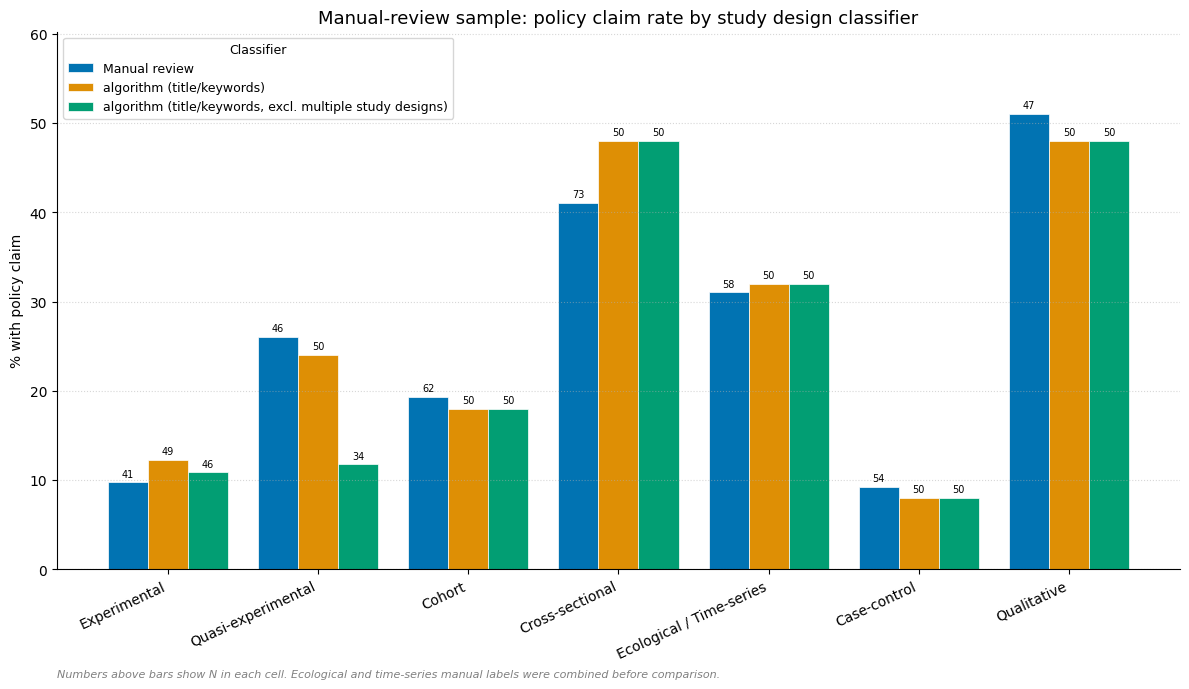

In [1]:
"""
Manual review analysis: compare policy claim rates by study design using the
completed design-review workbook (400 reviewed records).

Compares claim rates across:
    - manual_check1                    (manual design labels entered by reviewer)
    - design_combined                  (main automated classifier)
    - design_combined_unambiguous      (combined, multi-match rows blanked)

The reviewer labels in manual_check1 are lower-case, so labels are normalised
before comparison.
"""

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- CONFIG --------------------
INPUT_XLSX = Path("../table/manual_review_by_design_50_each_EC.xlsx")
OUTPUT_PNG = Path("../data/analysis/manual_review_claim_rate_by_design_sensitivity.png")

CLAIM_COL = "llm_policy_claim"
MANUAL_COL = "manual_check1"
CLASSIFIERS = [
    MANUAL_COL,
    "design_combined",
    "design_combined_unambiguous",
]

CLASSIFIER_LABELS = {
    MANUAL_COL: "Manual review",
    "design_combined": "algorithm (title/keywords)",
    "design_combined_unambiguous": "algorithm (title/keywords, excl. multiple study designs)",
}

DESIGN_ORDER = [
    "Experimental",
    "Quasi-experimental",
    "Cohort",
    "Cross-sectional",
    "Ecological / Time-series",
    "Case-control",
    "Qualitative",
]

MIN_N_TO_PLOT = 1


def normalize_design_label_auto(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text:
        return pd.NA
    key = re.sub(r"\s+", " ", text).strip().lower()
    mapping = {
        "experimental": "Experimental",
        "quasi-experimental": "Quasi-experimental",
        "quasi experimental": "Quasi-experimental",
        "cohort": "Cohort",
        "cross-sectional": "Cross-sectional",
        "cross sectional": "Cross-sectional",
        "ecological": "Ecological / Time-series",
        "ecological study": "Ecological / Time-series",
        "ecological / time-series": "Ecological / Time-series",
        "ecological/time-series": "Ecological / Time-series",
        "ecological / time series": "Ecological / Time-series",
        "ecological time-series": "Ecological / Time-series",
        "ecological time series": "Ecological / Time-series",
        "time-series": "Ecological / Time-series",
        "time series": "Ecological / Time-series",
        "times series": "Ecological / Time-series",
        "case-control": "Case-control",
        "case control": "Case-control",
        "qualitative": "Qualitative",
        "other/none": "Other/None",
        "other / none": "Other/None",
        "other none": "Other/None",
        "other": "Other/None",
        "none": "Other/None",
    }
    return mapping.get(key, text)


def normalize_design_label_manual(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text:
        return pd.NA
    key = re.sub(r"\s+", " ", text).strip().lower()
    mapping = {
        "experimental": "Experimental",
        "quasi-experimental": "Quasi-experimental",
        "quasi experimental": "Quasi-experimental",
        "cohort": "Cohort",
        "cross-sectional": "Cross-sectional",
        "cross sectional": "Cross-sectional",
        "ecological": "Ecological / Time-series",
        "ecological study": "Ecological / Time-series",
        "ecological / time-series": "Ecological / Time-series",
        "ecological/time-series": "Ecological / Time-series",
        "ecological / time series": "Ecological / Time-series",
        "ecological time-series": "Ecological / Time-series",
        "ecological time series": "Ecological / Time-series",
        "time-series": "Ecological / Time-series",
        "time series": "Ecological / Time-series",
        "times series": "Ecological / Time-series",
        "case-control": "Case-control",
        "case control": "Case-control",
        "qualitative": "Qualitative",
        "other/none": "Other/None",
        "other / none": "Other/None",
        "other none": "Other/None",
        "other": "Other/None",
        "none": "Other/None",
    }
    return mapping.get(key, text)


# -------------------- LOAD --------------------
df = pd.read_excel(INPUT_XLSX)

required_cols = {CLAIM_COL, MANUAL_COL, "design_combined", "design_combined_unambiguous"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"Missing required columns in {INPUT_XLSX.name}: {sorted(missing)}")

df[CLAIM_COL] = pd.to_numeric(df[CLAIM_COL], errors="coerce")
df = df[df[CLAIM_COL].notna()].copy()
df[CLAIM_COL] = df[CLAIM_COL].astype(bool)

# Keep the completed manual-review records only.
df[MANUAL_COL] = df[MANUAL_COL].apply(normalize_design_label_manual)
df = df[df[MANUAL_COL].notna()].copy()

for col in ["design_combined", "design_combined_unambiguous"]:
    df[col] = df[col].apply(normalize_design_label_auto)

print(f"Loaded {len(df)} reviewed records from {INPUT_XLSX.name}.")

# -------------------- CONCORDANCE --------------------
def cohen_kappa_from_labels(y_true, y_pred):
    paired = pd.DataFrame({"true": y_true, "pred": y_pred}).dropna()
    if paired.empty:
        return np.nan, 0, np.nan

    labels = sorted(set(paired["true"]).union(set(paired["pred"])))
    confusion = pd.crosstab(
        pd.Categorical(paired["true"], categories=labels),
        pd.Categorical(paired["pred"], categories=labels),
        dropna=False,
    ).to_numpy()
    n = confusion.sum()
    observed = np.trace(confusion) / n
    expected = (confusion.sum(axis=1) * confusion.sum(axis=0)).sum() / (n * n)
    kappa = (observed - expected) / (1 - expected) if expected != 1 else np.nan
    return kappa, int(n), observed * 100


kappa_rows = []
for clf in ["design_combined", "design_combined_unambiguous"]:
    kappa, n_pairs, pct_agreement = cohen_kappa_from_labels(df[MANUAL_COL], df[clf])
    kappa_rows.append({
        "comparison": f"Manual review vs {CLASSIFIER_LABELS[clf]}",
        "n": n_pairs,
        "percent_agreement": pct_agreement,
        "cohens_kappa": kappa,
    })

kappa_summary = pd.DataFrame(kappa_rows)
print("\n=== Study-design concordance with manual review ===")
print(kappa_summary.to_string(index=False, formatters={
    "percent_agreement": lambda x: f"{x:.1f}",
    "cohens_kappa": lambda x: f"{x:.3f}",
}))

# -------------------- BUILD LONG TABLE --------------------
rows = []
for clf in CLASSIFIERS:
    for design in DESIGN_ORDER:
        mask = df[clf] == design
        n = int(mask.sum())
        claims = df.loc[mask, CLAIM_COL]
        pct = (claims.mean() * 100) if n > 0 else np.nan
        rows.append({
            "classifier": clf,
            "classifier_label": CLASSIFIER_LABELS[clf],
            "design": design,
            "n": n,
            "pct_claim": pct,
        })

summary = pd.DataFrame(rows)

# -------------------- PRINT UNDERLYING NUMBERS --------------------
print("\n=== Policy claim rate (%) by design and classifier ===")
pct_wide = summary.pivot(index="design", columns="classifier_label", values="pct_claim")
pct_wide = pct_wide.reindex(DESIGN_ORDER)
pct_wide = pct_wide[[CLASSIFIER_LABELS[c] for c in CLASSIFIERS]]
print(pct_wide.round(1).to_string())

print("\n=== N per cell ===")
n_wide = summary.pivot(index="design", columns="classifier_label", values="n")
n_wide = n_wide.reindex(DESIGN_ORDER)
n_wide = n_wide[[CLASSIFIER_LABELS[c] for c in CLASSIFIERS]]
print(n_wide.astype("Int64").to_string())

# -------------------- PLOT --------------------
x = np.arange(len(DESIGN_ORDER))
bar_width = 0.8 / len(CLASSIFIERS)
colours = ["#0173B2", "#DE8F05", "#029E73"]

fig, ax = plt.subplots(figsize=(12, 7))

for i, clf in enumerate(CLASSIFIERS):
    sub = summary[summary["classifier"] == clf].set_index("design").reindex(DESIGN_ORDER)
    heights = sub["pct_claim"].to_numpy()
    ns = sub["n"].to_numpy()
    heights = np.where(ns >= MIN_N_TO_PLOT, heights, np.nan)

    offset = (i - (len(CLASSIFIERS) - 1) / 2) * bar_width
    bars = ax.bar(
        x + offset,
        heights,
        width=bar_width,
        color=colours[i],
        label=CLASSIFIER_LABELS[clf],
        edgecolor="white",
        linewidth=0.5,
    )

    for j, (bar, n) in enumerate(zip(bars, ns)):
        if np.isnan(heights[j]):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{int(n):,}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

ax.set_xticks(x)
ax.set_xticklabels(DESIGN_ORDER, rotation=25, ha="right")
ax.set_ylabel("% with policy claim")
ax.set_title("Manual-review sample: policy claim rate by study design classifier", fontsize=13)
ax.set_ylim(0, max(summary["pct_claim"].max() * 1.18, 55))
ax.legend(title="Classifier", loc="upper left", frameon=True, fontsize=9, title_fontsize=9)
ax.text(
    0.0,
    -0.20,
    "Numbers above bars show N in each cell. Ecological and time-series manual labels were combined before comparison.",
    transform=ax.transAxes,
    fontsize=8,
    color="gray",
    style="italic",
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

fig.tight_layout()
OUTPUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
print(f"\nSaved plot: {OUTPUT_PNG}")
